# 04 — Predicción de comandas

## Objetivo

El objetivo de este notebook es desarrollar y evaluar un sistema predictivo para estimar qué artículos se demandarán y cuántas unidades se venderán en el siguiente periodo de ventas.

Dentro del trabajo, esta predicción busca transformar el histórico de ventas en información útil para la planificación operativa del establecimiento. Anticipar la demanda por artículo puede ayudar a priorizar la preparación, ajustar aprovisionamientos y, si se dispone posteriormente de una tabla de recetas o composición de producto, traducir las unidades previstas a necesidades de ingredientes.

### Granularidad disponible

La fuente principal, `ventas_silver.parquet`, contiene las ventas de cada artículo agregadas por semana. Por tanto, con el histórico disponible, el problema predictivo se formula como **predecir las unidades de cada artículo en el siguiente periodo semanal.**

No se realizan predicciones diarias ni por turno para cada artículo, ya que esa granularidad no está disponible de forma consistente en todo el histórico.

Los tickets disponibles en PDF contienen información a nivel de línea de producto, pero cubren únicamente una parte limitada del periodo analizado. Por este motivo, no utilizamos como fuente principal del modelo de demanda. Su posible utilización para estudiar asociaciones o coocurrencias entre artículos se analiza posteriormente como una línea complementaria.

---

## Enfoque metodológico

El problema se plantea como un forecast global artículo x periodo, es decir, un mismo modelo aprende utilizando conjuntamente las observaciones históricas de los distintos artículos, incorporando tanto la identidad del producto como su comportamiento temporal.

La evaluación se diseña respetando estrictamente el orden temporal:

1. Se construye el panel histórico `artículo × periodo`.
2. Se generan variables utilizando únicamente información disponible antes del periodo objetivo.
3. Los últimos periodos se reservan como test final y no intervienen en la selección del modelo.
4. Sobre el conjunto de Development se realiza validación temporal mediante expanding window.
5. Se comparan bajo el mismo esquema tanto modelos sencillos de referencia (baselines) como modelos de machine learning.
6. El modelo se selecciona únicamente a partir de los resultados de Development.
7. Una vez congelada la decisión, se evalúa una única vez sobre el test final.

La métrica principal de selección será WAPE, complementada con MAE, RMSE, Bias y `Top-K overlap`. Esta última nos permite evaluar un aspecto especialmente relevante para el uso operativo, identificar correctamente los artículos que concentran la mayor parte de la demanda.

---

## Estructura del notebook

El análisis se estructura en:

1. carga y auditoría de las fuentes;
2. definición del universo de artículos;
3. construcción del panel `artículo × periodo`;
4. análisis exploratorio específico de demanda;
5. feature engineering de variables temporales y de contexto;
6. separación temporal entre Development y test final;
7. construcción de baselines;
8. entrenamiento de HistGradientBoosting Poisson y Random Forest;
9. validación temporal y selección del modelo exclusivamente sobre Development;
10. evaluación final sobre el holdout;
11. análisis del error y de la importancia de variables;
12. generación del forecast del siguiente periodo;
13. tratamiento de artículos con histórico insuficiente;
14. análisis complementario de coocurrencia entre productos.

## 1. Imports y configuración

En esta sección cargamos las librerías necesarias para el análisis, el modelado y la evaluación de resultados, y definimos las rutas de trabajo utilizadas por el notebook.

Para facilitar la reproducibilidad:

- fijamos una semilla común mediante `RANDOM_STATE = 42`;
- las rutas se construyen de forma relativa a la raíz del repositorio;
- los resultados específicos de este análisis los guardamos en carpetas separadas dentro de `results/`.

Los principales outputs generados por este notebook se almacenan en:

- `results/figures/comandas/`: figuras y visualizaciones;
- `results/predictions/`: predicciones y resultados exportables.

El modelado se realiza con `scikit-learn`, utilizando tanto modelos de referencia como algoritmos de machine learning. Las funciones de visualización mantienen el estilo común definido para el resto del proyecto.

In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas del repositorio
ROOT = Path.cwd().resolve()

if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

required_dirs = ['data', 'src']

if not all((ROOT / directory).exists() for directory in required_dirs):
    raise FileNotFoundError(
        'No se ha podido identificar correctamente la raíz del repositorio. '
        'Ejecuta el notebook desde la carpeta raíz del proyecto o desde notebooks/.'
    )

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

SILVER_DIR = ROOT / 'data' / 'silver' / 'snapshots'
GOLD_DIR = ROOT / 'data' / 'gold'

RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures' / 'comandas'
PREDICTIONS_DIR = RESULTS_DIR / 'predictions'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Estilo y visualización
from src.tfm_theme import apply_theme

apply_theme()

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

warnings.simplefilter('default')


### Parámetros principales

Los parámetros siguientes controlan el alcance del análisis y se centralizan
en una única celda para facilitar la reproducibilidad.

Las decisiones principales que hemos tomado son:

- Se mantienen las invitaciones porque el objetivo es predecir unidades demandadas,
  aunque no generen facturación, sí representan consumo real de producto.
- Los periodos incompletos se excluyen del entrenamiento principal para que el
  target represente periodos comparables.
- Se conservan umbrales para caracterizar un catálogo de artículos con mayor
  histórico, pero esta clasificación no se utilizará automáticamente para
  eliminar los artículos de baja frecuencia.
- Las variables temporales utilizan únicamente información anterior al periodo
  objetivo.
- Los últimos periodos se reservan como test final y no intervienen en la
  selección del modelo.
- La selección se realizará mediante validación temporal exclusivamente sobre
  Development.
- La métrica principal de selección será WAPE y la complementaremos con MAE,
  RMSE, Bias y `Top-K overlap`.
- La meteorología observada no se incorpora por defecto porque no representa la
  información meteorológica que estaría disponible al realizar una predicción
  futura.
- Festivos y eventos sí pueden utilizarse cuando son conocidos antes del
  periodo que se desea predecir.

In [2]:
# Configuración
# Target y limpieza específica del modelado
DROP_INVITATIONS = False
DROP_INCOMPLETE_PERIODS = True

# Caracterización del universo de artículos
# Estos umbrales se utilizarán para describir un subconjunto "core",
# pero no para excluir automáticamente los artículos de baja frecuencia.
MIN_POSITIVE_PERIODS = 8
MIN_TOTAL_UNITS = 20

# Variables temporales
# Historia reciente y de medio plazo.
# Todas estas variables se construirán desplazadas para evitar leakage.
LAGS = [1, 2, 4, 8]
ROLLING_WINDOWS = [4, 8]

# Validación temporal
N_TEST_PERIODS = 6
N_CV_SPLITS = 4
CV_TEST_PERIODS = 4

PRIMARY_METRIC = 'WAPE'
TOP_K = 20

# Contexto externo
# La meteorología observada no es segura para una inferencia futura si no
# tenemos una previsión equivalente en el momento de predicción.
# Para este análisis, asumimos que no se dispone de previsión meteorológica, por lo que
# no incorporaremos información de la meteorología observada.
INCLUDE_WEATHER = False

# Festivos y eventos sí pueden utilizarse si son conocidos antes del periodo.
INCLUDE_KNOWN_CALENDAR_CONTEXT = True


print('Configuración del experimento')
print('----------------------------')
print(f'Drop invitations: {DROP_INVITATIONS}')
print(f'Drop incomplete periods: {DROP_INCOMPLETE_PERIODS}')
print(f'Lags: {LAGS}')
print(f'Rolling windows: {ROLLING_WINDOWS}')
print(f'Final test periods: {N_TEST_PERIODS}')
print(f'CV splits: {N_CV_SPLITS}')
print(f'CV validation periods per split: {CV_TEST_PERIODS}')
print(f'Primary metric: {PRIMARY_METRIC}')
print(f'Top-K: {TOP_K}')
print(f'Include observed weather: {INCLUDE_WEATHER}')
print(f'Include known calendar context: {INCLUDE_KNOWN_CALENDAR_CONTEXT}')

Configuración del experimento
----------------------------
Drop invitations: False
Drop incomplete periods: True
Lags: [1, 2, 4, 8]
Rolling windows: [4, 8]
Final test periods: 6
CV splits: 4
CV validation periods per split: 4
Primary metric: WAPE
Top-K: 20
Include observed weather: False
Include known calendar context: True


## 2. Carga de datos

La fuente principal para la predicción de comandas es `ventas_silver.parquet`, ya que conserva la granularidad necesaria para este problema, una observación por artículo y periodo de ventas.

Esta tabla nos proporciona directamente el histórico necesario para construir el target de unidades vendidas por artículo.

Además, cargamos varias fuentes auxiliares:

- `articulos_silver.parquet`: metadatos e identificación de artículos.
- `departamentos_silver.parquet`: información de departamentos.
- `menu_silver.parquet`: referencia auxiliar del catálogo presente en carta.
- `tabla_maestra_diaria.parquet`: contexto diario integrado procedente de la capa Gold.
- `festivos_silver.parquet` y `eventos_silver.parquet`: información de calendario conocida con antelación.

La tabla Gold diaria no sustituye a `ventas_silver` como fuente principal porque su granularidad es diaria y no conserva la dimensión artículo. La utilizamos únicamente como fuente de contexto que posteriormente puede agregarse al mismo intervalo temporal que las ventas.

In [3]:
# Carga de datasets

ventas = pd.read_parquet(
    SILVER_DIR / 'ventas_silver.parquet'
)

articulos = pd.read_parquet(
    SILVER_DIR / 'articulos_silver.parquet'
)

departamentos = pd.read_parquet(
    SILVER_DIR / 'departamentos_silver.parquet'
)

menu = pd.read_parquet(
    SILVER_DIR / 'menu_silver.parquet'
)

gold_daily = pd.read_parquet(
    GOLD_DIR / 'tabla_maestra_diaria.parquet'
)

festivos = pd.read_parquet(
    SILVER_DIR / 'festivos_silver.parquet'
)

eventos = pd.read_parquet(
    SILVER_DIR / 'eventos_silver.parquet'
)


# Comprobaciones iniciales

datasets = {
    'ventas': ventas,
    'articulos': articulos,
    'departamentos': departamentos,
    'menu': menu,
    'gold_daily': gold_daily,
    'festivos': festivos,
    'eventos': eventos,
}

print('Datasets cargados')
print('-----------------')

for name, df in datasets.items():
    print(
        f'{name:<15} '
        f'{df.shape[0]:>6} filas x '
        f'{df.shape[1]:>3} columnas'
    )


# Cobertura temporal de ventas
ventas_dates = ventas.copy()

ventas_dates['report_start'] = pd.to_datetime(
    ventas_dates['report_start'],
    errors='coerce',
)

ventas_dates['report_end'] = pd.to_datetime(
    ventas_dates['report_end'],
    errors='coerce',
)

print('\nCobertura temporal de ventas')
print('----------------------------')
print(
    'Inicio:',
    ventas_dates['report_start'].min().date(),
)
print(
    'Fin:',
    ventas_dates['report_end'].max().date(),
)
print(
    'Periodos únicos:',
    ventas_dates[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .shape[0],
)
print(
    'Artículos observados:',
    ventas_dates['article_code'].nunique(),
)

display(ventas.head())

Datasets cargados
-----------------
ventas            5532 filas x  14 columnas
articulos          405 filas x   4 columnas
departamentos       23 filas x   3 columnas
menu               405 filas x   3 columnas
gold_daily         242 filas x  37 columnas
festivos            57 filas x   5 columnas
eventos             48 filas x  20 columnas

Cobertura temporal de ventas
----------------------------
Inicio: 2025-10-01
Fin: 2026-07-09
Periodos únicos: 41
Artículos observados: 251


,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,department_code,department_name,article_code,article_name,units,amount,es_invitacion
0,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,1901,EMPANADILLA CRIOLLA,32.0,128.00000,False
1,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2031,ROSSINI,19.0,129.54542,False
2,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2239,BOMBONES DE WAGYU Y FOIE,1.0,7.27273,False
3,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2303,BOCATIN DE CALAMARES,19.0,122.63640,False
4,01-05-10.xls,2025-10-01,2025-10-05,2026-07-09,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,1,TAPAS CALIENTES,2306,PAN BAO DE COCHINITA PIBIL,2.0,11.81818,False


## 3. Auditoría de la fuente de ventas

Antes de construir el dataset de modelado hacemos una auditoría específica
de la fuente de ventas.

El objetivo es comprobar:

- La cobertura y duración real de los periodos de reporte.
- El número de artículos observados en cada periodo.
- Las unidades e importes agregados.
- La existencia de registros con unidades o importes negativos.
- Posibles duplicados en la clave `periodo x artículo`.
- La presencia de invitaciones.
- Valores ausentes en las variables necesarias para construir el target.

Con esta auditoría no modificamos la capa Silver. La finalidad es justificar
explícitamente las decisiones de limpieza que aplicaremos posteriormente
únicamente al dataset de modelado.

In [4]:
# Copia de trabajo
sales = ventas.copy()

sales['report_start'] = pd.to_datetime(
    sales['report_start'],
    errors='coerce',
)

sales['report_end'] = pd.to_datetime(
    sales['report_end'],
    errors='coerce',
)

sales['units'] = pd.to_numeric(
    sales['units'],
    errors='coerce',
)

sales['amount'] = pd.to_numeric(
    sales['amount'],
    errors='coerce',
)

sales['period_days'] = (
    sales['report_end'] - sales['report_start']
).dt.days + 1

# Auditoría por periodo
period_audit = (
    sales.groupby(
        ['report_start', 'report_end'],
        as_index=False,
    )
    .agg(
        period_days=('period_days', 'first'),
        n_rows=('article_code', 'size'),
        n_articles=('article_code', 'nunique'),
        total_units=('units', 'sum'),
        total_amount=('amount', 'sum'),
    )
    .sort_values('report_start')
    .reset_index(drop=True)
)


print('Auditoría de ventas')
print('-------------------')

print(f'Filas: {len(sales):,}')
print(f'Periodos: {len(period_audit)}')
print(f'Artículos observados: {sales["article_code"].nunique()}')

print(
    'Cobertura:',
    period_audit['report_start'].min().date(),
    '→',
    period_audit['report_end'].max().date(),
)


# Duración de los periodos
print('\nDuración de los periodos')
print('------------------------')

display(
    period_audit[
        'period_days'
    ]
    .value_counts()
    .sort_index()
    .rename('n_periodos')
    .to_frame()
)


# Missings en variables esenciales
essential_columns = [
    'report_start',
    'report_end',
    'article_code',
    'units',
]

missing_essential = (
    sales[essential_columns]
    .isna()
    .sum()
    .rename('missing')
    .to_frame()
)

print('\nMissing en variables esenciales')
print('-------------------------------')
display(missing_essential)

# Unidades e importes negativos
negative_units = sales.loc[
    sales['units'] < 0
].copy()

negative_amount = sales.loc[
    sales['amount'] < 0
].copy()

print(f'\nFilas con unidades negativas: {len(negative_units)}')
print(f'Filas con importe negativo: {len(negative_amount)}')

if not negative_units.empty:
    display(
        negative_units[
            [
                'report_start',
                'report_end',
                'article_code',
                'article_name',
                'units',
                'amount',
            ]
        ]
    )

if not negative_amount.empty:
    display(
        negative_amount[
            [
                'report_start',
                'report_end',
                'article_code',
                'article_name',
                'units',
                'amount',
            ]
        ]
    )


# Duplicados artículo x periodo
duplicate_key = sales.duplicated(
    subset=[
        'report_start',
        'report_end',
        'article_code',
    ],
    keep=False,
)

print(
    '\nFilas pertenecientes a claves '
    f'periodo × artículo duplicadas: {duplicate_key.sum()}'
)

if duplicate_key.any():
    display(
        sales.loc[
            duplicate_key,
            [
                'report_start',
                'report_end',
                'article_code',
                'article_name',
                'units',
                'amount',
            ],
        ].sort_values(
            [
                'report_start',
                'article_code',
            ]
        )
    )

# Invitaciones
if 'es_invitacion' in sales.columns:
    print('\nInvitaciones')
    print('------------')

    display(
        sales[
            'es_invitacion'
        ]
        .value_counts(dropna=False)
        .rename('n_filas')
        .to_frame()
    )
else:
    print(
        '\nLa fuente no contiene la columna '
        '`es_invitacion`.'
    )

# Periodos no semanales
non_weekly_periods = period_audit.loc[
    period_audit['period_days'] != 7
].copy()

print(
    f'\nPeriodos con duración distinta de 7 días: '
    f'{len(non_weekly_periods)}'
)

if not non_weekly_periods.empty:
    display(non_weekly_periods)




display(period_audit.head(10))

Auditoría de ventas
-------------------
Filas: 5,532
Periodos: 41
Artículos observados: 251
Cobertura: 2025-10-01 → 2026-07-09

Duración de los periodos
------------------------


,n_periodos
period_days,
4,1
5,1
7,39



Missing en variables esenciales
-------------------------------


,missing
report_start,0
report_end,0
article_code,0
units,0



Filas con unidades negativas: 0
Filas con importe negativo: 0

Filas pertenecientes a claves periodo × artículo duplicadas: 0

Invitaciones
------------


,n_filas
es_invitacion,
False,5506
True,26



Periodos con duración distinta de 7 días: 2


,report_start,report_end,period_days,n_rows,n_articles,total_units,total_amount
0,2025-10-01,2025-10-05,5,125,125,1919.0,10803.93642
40,2026-07-06,2026-07-09,4,93,93,693.0,4552.68184


,report_start,report_end,period_days,n_rows,n_articles,total_units,total_amount
0,2025-10-01,2025-10-05,5,125,125,1919.0,10803.93642
1,2025-10-06,2025-10-12,7,142,142,2523.0,15045.95446
2,2025-10-13,2025-10-19,7,129,129,1976.0,15082.97273
3,2025-10-20,2025-10-26,7,134,134,2279.0,13728.26360
4,2025-10-27,2025-11-02,7,129,129,2124.0,13105.06365
5,2025-11-03,2025-11-09,7,139,139,2000.0,14923.90904
6,2025-11-10,2025-11-16,7,150,150,2506.0,15588.33630
7,2025-11-17,2025-11-23,7,144,144,2370.0,15055.99094
8,2025-11-24,2025-11-30,7,142,142,2245.0,15114.04551
9,2025-12-01,2025-12-07,7,141,141,2361.0,14852.63636


### Preparación del histórico para modelado

La auditoría nos muestra que la fuente presenta una calidad adecuada para construir
el problema predictivo, no existen valores ausentes en las variables
esenciales, unidades negativas ni claves duplicadas `periodo x artículo`.

De los 41 periodos disponibles, 39 corresponden a intervalos completos de
7 días. Los periodos inicial y final tienen duraciones de 5 y 4 días,
respectivamente.

Estos periodos incompletos se excluyen del histórico que utilizamos para el
modelado. La decisión no responde a un problema de calidad del dato, sino de
comparabilidad temporal. Utilizar sus unidades como target o como referencia
para lags y medias móviles introduciría valores correspondientes a ventanas de
exposición distintas.

Las invitaciones se mantienen. Aunque no generen facturación, representan
unidades realmente servidas y, por tanto forman parte de la demanda física que
se pretende anticipar con el modelo de comandas.

No se aplican otras eliminaciones sobre la fuente en esta etapa.

In [5]:
# Construcción del histórico modelable
sales_model = sales.copy()

rows_initial = len(sales_model)
periods_initial = (
    sales_model[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .shape[0]
)


# Periodos completos
if DROP_INCOMPLETE_PERIODS:
    sales_model = sales_model.loc[
        sales_model['period_days'] == 7
    ].copy()


# Invitaciones
if DROP_INVITATIONS and 'es_invitacion' in sales_model.columns:
    sales_model = sales_model.loc[
        ~sales_model['es_invitacion'].fillna(False)
    ].copy()

# Orden temporal
sales_model = (
    sales_model
    .sort_values(
        [
            'report_start',
            'article_code',
        ]
    )
    .reset_index(drop=True)
)


# Resumen
periods_final = (
    sales_model[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .shape[0]
)

print('Histórico preparado para modelado')
print('---------------------------------')
print(f'Filas iniciales: {rows_initial:,}')
print(f'Filas finales: {len(sales_model):,}')
print(f'Filas excluidas: {rows_initial - len(sales_model):,}')
print()
print(f'Periodos iniciales: {periods_initial}')
print(f'Periodos completos conservados: {periods_final}')
print(
    'Cobertura modelable:',
    sales_model['report_start'].min().date(),
    '→',
    sales_model['report_end'].max().date(),
)
print(
    'Artículos observados:',
    sales_model['article_code'].nunique(),
)

if 'es_invitacion' in sales_model.columns:
    print(
        'Filas de invitaciones conservadas:',
        int(
            sales_model['es_invitacion']
            .fillna(False)
            .sum()
        ),
    )

Histórico preparado para modelado
---------------------------------
Filas iniciales: 5,532
Filas finales: 5,314
Filas excluidas: 218

Periodos iniciales: 41
Periodos completos conservados: 39
Cobertura modelable: 2025-10-06 → 2026-07-05
Artículos observados: 251
Filas de invitaciones conservadas: 23


## 4. Universo de artículos y cobertura histórica

La demanda por artículo tiene una estructura desigual. Algunos productos
aparecen de forma recurrente una gran parte del histórico, mientras que
otros están únicamente en unos pocos periodos.

Antes de construir el panel de modelado caracterizamos:

- Número de periodos en los que se observa cada artículo.
- Número de periodos con unidades positivas.
- Unidades acumuladas.
- Cobertura respecto al total de periodos completos.
- Primera y última aparición en el histórico.

Definimos además un subconjunto descriptivo de artículos `core` con los
umbrales:

- Al menos `MIN_POSITIVE_PERIODS` periodos con demanda positiva.
- Al menos `MIN_TOTAL_UNITS` unidades acumuladas.

Esta clasificación la utilizamos únicamente para analizar la profundidad del
histórico disponible. Los artículos que no cumplen estos criterios no se
eliminan automáticamente del problema predictivo, ya que una baja frecuencia
puede representar demanda intermitente, productos nuevos o artículos de baja
rotación y no necesariamente datos inválidos.

Tampoco interpolamos como demanda cero los periodos en los que un artículo
no aparece. Sin una señal histórica explícita de disponibilidad o presencia en
carta, una ausencia puede corresponder tanto a demanda nula como a
indisponibilidad, retirada temporal o falta de observación.

In [6]:
# Perfil histórico por artículo
n_complete_periods = (
    sales_model[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .shape[0]
)

article_profile = (
    sales_model
    .groupby(
        'article_code',
        as_index=False,
    )
    .agg(
        article_name=('article_name', 'last'),
        observed_periods=('report_start', 'nunique'),
        positive_periods=(
            'units',
            lambda s: int((s > 0).sum()),
        ),
        total_units=('units', 'sum'),
        mean_units_observed=('units', 'mean'),
        median_units_observed=('units', 'median'),
        first_observed=('report_start', 'min'),
        last_observed=('report_start', 'max'),
    )
)


# Cobertura histórica
article_profile['history_coverage'] = (
    article_profile['observed_periods']
    / n_complete_periods
)

article_profile['is_core'] = (
    (
        article_profile['positive_periods']
        >= MIN_POSITIVE_PERIODS
    )
    &
    (
        article_profile['total_units']
        >= MIN_TOTAL_UNITS
    )
)


# Antigüedad desde la última observación
last_complete_period = sales_model['report_start'].max()

period_order = (
    sales_model[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .sort_values('report_start')
    .reset_index(drop=True)
)

period_position = {
    date: idx
    for idx, date in enumerate(
        period_order['report_start']
    )
}

last_period_position = len(period_order) - 1

article_profile['periods_since_last_observation'] = (
    article_profile['last_observed']
    .map(
        lambda date:
        last_period_position
        - period_position.get(date, last_period_position)
    )
)


# Resumen
n_articles = len(article_profile)
n_core = int(article_profile['is_core'].sum())
n_non_core = n_articles - n_core

print('Universo histórico de artículos')
print('------------------------------')
print(f'Periodos completos: {n_complete_periods}')
print(f'Artículos observados: {n_articles}')
print(
    f'Artículos core: {n_core} '
    f'({n_core / n_articles:.1%})'
)
print(
    f'Artículos no core: {n_non_core} '
    f'({n_non_core / n_articles:.1%})'
)

print('\nCobertura histórica')
print('-------------------')
print(
    'Mediana de periodos observados:',
    f'{article_profile["observed_periods"].median():.1f}'
)
print(
    'Mediana de cobertura:',
    f'{article_profile["history_coverage"].median():.1%}'
)

print('\nDistribución de artículos por cobertura')
print('---------------------------------------')
print(
    '< 25% de periodos:',
    int(
        (
            article_profile['history_coverage']
            < 0.25
        ).sum()
    ),
)
print(
    '< 50% de periodos:',
    int(
        (
            article_profile['history_coverage']
            < 0.50
        ).sum()
    ),
)
print(
    '>= 75% de periodos:',
    int(
        (
            article_profile['history_coverage']
            >= 0.75
        ).sum()
    ),
)


display(
    article_profile
    .sort_values(
        [
            'total_units',
            'observed_periods',
        ],
        ascending=False,
    )
    .head(20)
)

Universo histórico de artículos
------------------------------
Periodos completos: 39
Artículos observados: 251
Artículos core: 161 (64.1%)
Artículos no core: 90 (35.9%)

Cobertura histórica
-------------------
Mediana de periodos observados: 20.0
Mediana de cobertura: 51.3%

Distribución de artículos por cobertura
---------------------------------------
< 25% de periodos: 84
< 50% de periodos: 125
>= 75% de periodos: 100


,article_code,article_name,observed_periods,positive_periods,total_units,mean_units_observed,median_units_observed,first_observed,last_observed,history_coverage,is_core,periods_since_last_observation
19,96,RACIÓN DE PAN,39,39,14908.0,382.256410,372.0,2025-10-06,2026-06-29,1.000000,True,0
31,1637,COPA DE VICTORIA,39,39,5119.0,131.256410,135.0,2025-10-06,2026-06-29,1.000000,True,0
34,1690,CAFÉ E INFUSIONES,39,39,4480.0,114.871795,117.0,2025-10-06,2026-06-29,1.000000,True,0
113,2138,SAM DE GAMBAS,39,39,3025.0,77.564103,81.0,2025-10-06,2026-06-29,1.000000,True,0
75,1945,EXTRA CROQUETA DE JAMON,39,39,2781.0,71.307692,65.0,2025-10-06,2026-06-29,1.000000,True,0
180,2309,AGUA 70CL,39,39,2674.0,68.564103,71.0,2025-10-06,2026-06-29,1.000000,True,0
1,2,RAVIOLI DE RABO DE TERNERA,39,39,2378.0,60.974359,56.0,2025-10-06,2026-06-29,1.000000,True,0
35,1691,CERVEZA VICTORIA,39,39,2016.0,51.692308,46.0,2025-10-06,2026-06-29,1.000000,True,0
225,2381,PAN BAO DE CARRILLERA DE CERDO,39,39,1967.0,50.435897,50.0,2025-10-06,2026-06-29,1.000000,True,0
80,1974,ZAMBURIÑAS A LA BRASA,35,35,1903.0,54.371429,54.0,2025-11-03,2026-06-29,0.897436,True,0


### Artículos frente a platos

La fuente de ventas no contiene exclusivamente platos de cocina. El catálogo
incluye también bebidas, cafés, vinos y otras líneas de venta.

En este trabajo se predice la demanda de artículos commandables, entendiendo
como tal cualquier producto que pueda aparecer en una comanda y cuya demanda
tenga interés para la planificación operativa.

No se aplica un filtro automático por departamento. Excluir bebidas u otras
categorías introduciría una decisión de negocio que no es necesaria para el
objetivo general de anticipar la demanda.

La salida del modelo puede filtrarse posteriormente por departamento si se 
deseara analizar únicamente cocina, bebidas u otra familia concreta de
productos.

In [7]:
# Distribución de la demanda por departamento
department_summary = (
    sales_model
    .groupby(
        [
            'department_code',
            'department_name',
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        n_articles=('article_code', 'nunique'),
        observed_rows=('article_code', 'size'),
        total_units=('units', 'sum'),
        total_amount=('amount', 'sum'),
    )
    .sort_values(
        'total_units',
        ascending=False,
    )
    .reset_index(drop=True)
)

department_summary['units_share'] = (
    department_summary['total_units']
    / department_summary['total_units'].sum()
)

department_summary['amount_share'] = (
    department_summary['total_amount']
    / department_summary['total_amount'].sum()
)

print('Demanda por departamento')
print('-------------------------')
print(
    'Departamentos observados:',
    department_summary['department_code'].nunique(),
)

display(department_summary)

Demanda por departamento
-------------------------
Departamentos observados: 18


,department_code,department_name,n_articles,observed_rows,total_units,total_amount,units_share,amount_share
0,15,OTROS,3,112,15815.0,50619.59210,0.166546,0.084400
1,5,CERVEZAS,17,409,10996.0,42472.57796,0.115797,0.070816
2,28,CLASICOS,7,247,9334.0,53270.15819,0.098295,0.088820
3,13,POSTRES,17,472,9153.0,38868.71000,0.096389,0.064807
4,3,CARTA,29,829,9095.0,158930.34859,0.095778,0.264991
5,4,REFRESCOS,20,573,9086.0,25919.45866,0.095683,0.043217
6,1,TAPAS CALIENTES,9,284,7576.0,47206.29226,0.079782,0.078709
7,14,SUGERENCIAS,27,515,6460.0,61927.19582,0.068029,0.103254
8,22,EXTRAS,9,216,3757.0,7573.03605,0.039564,0.012627
9,9,TINTOS,33,476,3428.0,29419.25449,0.036100,0.049052


## 5. Construcción del panel artículo x periodo

El dataset de ventas contiene únicamente combinaciones `artículo x periodo`
observadas. Por tanto, no constituye un panel rectangular completo. Un artículo
puede aparecer en una semana y no aparecer en la siguiente.

Una ausencia no se transforma automáticamente en `units = 0`. Sin un histórico
explícito de disponibilidad del producto, no es posible distinguir con certeza
entre:

- Demanda realmente nula.
- Producto temporalmente no disponible.
- Retirada de carta.
- Artículo nuevo.
- Ausencia de observación.

Para preservar esta incertidumbre, el target solo se define en las combinaciones
realmente observadas.

Construimos un índice temporal común de periodos completos. Este
índice permitirá posteriormente generar lags referidos a semanas calendario
reales. Así, `lag_1` significará estrictamente el periodo inmediatamente
anterior y no simplemente la última observación disponible del artículo.

Esta decisión evita introducir una continuidad temporal artificial en productos
de demanda intermitente.

In [8]:
# Indice temporal común
periods = (
    sales_model[
        ['report_start', 'report_end']
    ]
    .drop_duplicates()
    .sort_values('report_start')
    .reset_index(drop=True)
)

periods['period_index'] = np.arange(len(periods))

print('Calendario de modelado')
print('----------------------')
print(f'Periodos completos: {len(periods)}')
print(
    'Cobertura:',
    periods['report_start'].min().date(),
    '→',
    periods['report_end'].max().date(),
)


# Panel observado artículo x periodo

article_period = (
    sales_model
    .merge(
        periods,
        on=[
            'report_start',
            'report_end',
        ],
        how='left',
        validate='many_to_one',
    )
    .sort_values(
        [
            'article_code',
            'period_index',
        ]
    )
    .reset_index(drop=True)
)


# Comprobaciones estructurales

expected_full_grid = (
    article_period['article_code'].nunique()
    * periods['period_index'].nunique()
)

observed_combinations = len(article_period)

panel_density = (
    observed_combinations
    / expected_full_grid
)

print('\nPanel artículo × periodo')
print('------------------------')
print(
    f'Artículos: '
    f'{article_period["article_code"].nunique()}'
)
print(
    f'Combinaciones observadas: '
    f'{observed_combinations:,}'
)
print(
    f'Combinaciones posibles en panel completo: '
    f'{expected_full_grid:,}'
)
print(
    f'Densidad observada: '
    f'{panel_density:.1%}'
)
print(
    f'Ausencias artículo-periodo: '
    f'{expected_full_grid - observed_combinations:,}'
)

# Comprobación de unicidad
duplicate_panel_key = article_period.duplicated(
    subset=[
        'article_code',
        'period_index',
    ],
).sum()

print(
    f'Duplicados artículo × periodo: '
    f'{duplicate_panel_key}'
)


display(
    article_period[
        [
            'period_index',
            'report_start',
            'report_end',
            'article_code',
            'article_name',
            'department_name',
            'units',
            'amount',
        ]
    ]
    .head(20)
)

Calendario de modelado
----------------------
Periodos completos: 39
Cobertura: 2025-10-06 → 2026-07-05

Panel artículo × periodo
------------------------
Artículos: 251
Combinaciones observadas: 5,314
Combinaciones posibles en panel completo: 9,789
Densidad observada: 54.3%
Ausencias artículo-periodo: 4,475
Duplicados artículo × periodo: 0


,period_index,report_start,report_end,article_code,article_name,department_name,units,amount
0,0,2025-10-06,2025-10-12,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,32.0,198.18195
1,1,2025-10-13,2025-10-19,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,20.0,112.18190
2,2,2025-10-20,2025-10-26,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28.0,155.81828
3,3,2025-10-27,2025-11-02,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,18.0,107.63643
4,4,2025-11-03,2025-11-09,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,24.0,145.09101
5,5,2025-11-10,2025-11-16,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,26.0,156.00007
6,6,2025-11-17,2025-11-23,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28.0,195.27281
7,7,2025-11-24,2025-11-30,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,23.0,153.81825
8,8,2025-12-01,2025-12-07,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,28.0,181.09097
9,9,2025-12-08,2025-12-14,1,NUESTRAS CROQUETAS DE JAMON,CLASICOS,32.0,202.90920


## 6. Ingeniería de variables históricas

Las variables temporales las construimos respetando tanto el orden cronológico
como las ausencias del panel.

Para ello generamos internamente una rejilla completa `artículo x periodo`.
Las combinaciones no observadas se mantienen como valores ausentes y
no se imputan como cero.

Esta rejilla la utilizamos únicamente para calcular correctamente las variables
temporales:

- `lag_1`, `lag_2`, `lag_4` y `lag_8`: unidades del artículo exactamente
  1, 2, 4 u 8 periodos antes.
- Medias móviles de 4 y 8 periodos, calculadas exclusivamente con periodos
  anteriores.
- Número de observaciones disponibles dentro de cada ventana.
- Media histórica acumulada anterior al periodo actual.

Así una ausencia histórica permanece explícita y un lag representa
una distancia temporal real, no simplemente la última observación disponible.

Todas las transformaciones utilizan exclusivamente información anterior al
periodo objetivo para evitar data leakage.

In [9]:
# Rejilla completa artículo × periodo

article_metadata = (
    article_period
    .sort_values('period_index')
    .groupby(
        'article_code',
        as_index=False,
    )
    .agg(
        article_name=('article_name', 'last'),
        department_code=('department_code', 'last'),
        department_name=('department_name', 'last'),
    )
)

full_grid = (
    pd.MultiIndex.from_product(
        [
            article_metadata['article_code'],
            periods['period_index'],
        ],
        names=[
            'article_code',
            'period_index',
        ],
    )
    .to_frame(index=False)
    .merge(
        periods,
        on='period_index',
        how='left',
        validate='many_to_one',
    )
    .merge(
        article_metadata,
        on='article_code',
        how='left',
        validate='many_to_one',
    )
)


# Incorporación del target observado

observed_values = article_period[
    [
        'article_code',
        'period_index',
        'units',
        'amount',
    ]
].copy()

full_grid = full_grid.merge(
    observed_values,
    on=[
        'article_code',
        'period_index',
    ],
    how='left',
    validate='one_to_one',
)

full_grid['target_observed'] = (
    full_grid['units'].notna()
)

full_grid = (
    full_grid
    .sort_values(
        [
            'article_code',
            'period_index',
        ]
    )
    .reset_index(drop=True)
)


# Lags de calendario

for lag in LAGS:
    full_grid[f'units_lag_{lag}'] = (
        full_grid
        .groupby('article_code')['units']
        .shift(lag)
    )


# Medias móviles causales

for window in ROLLING_WINDOWS:

    shifted_units = (
        full_grid
        .groupby('article_code')['units']
        .shift(1)
    )

    full_grid[f'units_rolling_mean_{window}'] = (
        shifted_units
        .groupby(full_grid['article_code'])
        .rolling(
            window=window,
            min_periods=1,
        )
        .mean()
        .reset_index(
            level=0,
            drop=True,
        )
    )

    full_grid[f'units_rolling_count_{window}'] = (
        shifted_units
        .groupby(full_grid['article_code'])
        .rolling(
            window=window,
            min_periods=1,
        )
        .count()
        .reset_index(
            level=0,
            drop=True,
        )
    )


# Media histórica acumulada anterior

full_grid['units_expanding_mean_prior'] = (
    full_grid
    .groupby('article_code')['units']
    .transform(
        lambda s:
        s.shift(1)
        .expanding(
            min_periods=1,
        )
        .mean()
    )
)


# Número de observaciones históricas disponibles

full_grid['n_prior_observations'] = (
    full_grid
    .groupby('article_code')['target_observed']
    .transform(
        lambda s:
        s.astype('int8')
        .shift(1, fill_value=0)
        .cumsum()
    )
)


# Recuperamos únicamente targets realmente observados

model_data = (
    full_grid.loc[
        full_grid['target_observed']
    ]
    .copy()
    .sort_values(
        [
            'period_index',
            'article_code',
        ]
    )
    .reset_index(drop=True)
)


# Auditoria de Features históricas

history_features = (
    [f'units_lag_{lag}' for lag in LAGS]
    +
    [
        f'units_rolling_mean_{window}'
        for window in ROLLING_WINDOWS
    ]
    +
    [
        f'units_rolling_count_{window}'
        for window in ROLLING_WINDOWS
    ]
    +
    [
        'units_expanding_mean_prior',
        'n_prior_observations',
    ]
)

feature_coverage = (
    model_data[history_features]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .rename('coverage')
    .to_frame()
)

print('Features históricas')
print('-------------------')
print(f'Filas de la rejilla completa: {len(full_grid):,}')
print(f'Targets observados para modelado: {len(model_data):,}')
print(f'Features históricas creadas: {len(history_features)}')

print('\nCobertura de Features')
print('---------------------')
display(feature_coverage)


# Comprobación visual de causalidad temporal

example_article_code = 1

display(
    model_data.loc[
        model_data['article_code'] == example_article_code,
        [
            'period_index',
            'report_start',
            'article_code',
            'article_name',
            'units',
            'units_lag_1',
            'units_lag_2',
            'units_lag_4',
            'units_lag_8',
            'units_rolling_mean_4',
            'units_rolling_mean_8',
            'units_expanding_mean_prior',
            'n_prior_observations',
        ],
    ]
    .head(12)
)

Features históricas
-------------------
Filas de la rejilla completa: 9,789
Targets observados para modelado: 5,314
Features históricas creadas: 10

Cobertura de Features
---------------------


,coverage
n_prior_observations,1.000000
units_rolling_count_8,1.000000
units_rolling_count_4,1.000000
units_expanding_mean_prior,0.952766
units_rolling_mean_8,0.941475
units_rolling_mean_4,0.922281
units_lag_1,0.819533
units_lag_2,0.793752
units_lag_4,0.745390
units_lag_8,0.652051


,period_index,report_start,article_code,article_name,units,units_lag_1,units_lag_2,units_lag_4,units_lag_8,units_rolling_mean_4,units_rolling_mean_8,units_expanding_mean_prior,n_prior_observations
0,0,2025-10-06,1,NUESTRAS CROQUETAS DE JAMON,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
142,1,2025-10-13,1,NUESTRAS CROQUETAS DE JAMON,20.0,32.0,NaN,NaN,NaN,32.000000,32.000000,32.000000,1
271,2,2025-10-20,1,NUESTRAS CROQUETAS DE JAMON,28.0,20.0,32.0,NaN,NaN,26.000000,26.000000,26.000000,2
405,3,2025-10-27,1,NUESTRAS CROQUETAS DE JAMON,18.0,28.0,20.0,NaN,NaN,26.666667,26.666667,26.666667,3
534,4,2025-11-03,1,NUESTRAS CROQUETAS DE JAMON,24.0,18.0,28.0,32.0,NaN,24.500000,24.500000,24.500000,4
673,5,2025-11-10,1,NUESTRAS CROQUETAS DE JAMON,26.0,24.0,18.0,20.0,NaN,22.500000,24.400000,24.400000,5
823,6,2025-11-17,1,NUESTRAS CROQUETAS DE JAMON,28.0,26.0,24.0,28.0,NaN,24.000000,24.666667,24.666667,6
967,7,2025-11-24,1,NUESTRAS CROQUETAS DE JAMON,23.0,28.0,26.0,18.0,NaN,24.000000,25.142857,25.142857,7
1109,8,2025-12-01,1,NUESTRAS CROQUETAS DE JAMON,28.0,23.0,28.0,24.0,32.0,25.250000,24.875000,24.875000,8
1250,9,2025-12-08,1,NUESTRAS CROQUETAS DE JAMON,32.0,28.0,23.0,26.0,20.0,26.250000,24.375000,25.222222,9


In [10]:

# Auditoría de fuentes de contexto
print('Gold diario')
print('-----------')
print(f'Shape: {gold_daily.shape}')
print('Columnas:')
print(list(gold_daily.columns))

print('\nFestivos')
print('--------')
print(f'Shape: {festivos.shape}')
print('Columnas:')
print(list(festivos.columns))
display(festivos.head())

print('\nEventos')
print('-------')
print(f'Shape: {eventos.shape}')
print('Columnas:')
print(list(eventos.columns))
display(eventos.head())

Gold diario
-----------
Shape: (242, 37)
Columnas:
['fecha', 'num_tickets', 'facturacion', 'ticket_medio', 'ticket_mediano', 'dia_semana', 'num_dia', 'mes', 'es_festivo', 'festivo_nombre', 'tiene_evento', 'intensidad_evento', 'impacto_evento', 'direccion_evento', 'categoria_evento', 'cat_evento', 'n_reservas_cancelada', 'n_reservas_completada', 'n_reservas_liberada', 'n_reservas_no_show', 'comensales_cancelada', 'comensales_completada', 'comensales_liberada', 'comensales_no_show', 'temperature_mean', 'temperature_max', 'temperature_min', 'precipitation_mm', 'precipitation_hours', 'wind_speed_max', 'sunshine_duration_h', 'n_reservas_total', 'tasa_no_show', 'tasa_cancelacion', 'tasa_liberada', 'es_fin_de_semana', 'es_lunes']

Festivos
--------
Shape: (57, 5)
Columnas:
['fecha', 'festivo_nombre', 'es_festivo', 'dia_semana', 'nivel']


,fecha,festivo_nombre,es_festivo,dia_semana,nivel
0,2023-01-01,Año Nuevo,1,Domingo,nacional_autonomico
1,2023-01-06,Epifanía del Señor,1,Viernes,nacional_autonomico
2,2023-03-20,Lunes siguiente a San José,1,Lunes,nacional_autonomico
3,2023-04-06,Jueves Santo,1,Jueves,nacional_autonomico
4,2023-04-07,Viernes Santo,1,Viernes,nacional_autonomico



Eventos
-------
Shape: (48, 20)
Columnas:
['event_id', 'fecha_inicio', 'fecha_fin', 'nombre_evento', 'categoria', 'subcategoria', 'ambito', 'ubicacion', 'proximidad_la_roca', 'impacto_esperado', 'intensidad_sugerida', 'direccion_demanda', 'franja_probable', 'segmento_cliente', 'confianza_fecha', 'estimado', 'feature_sugerida', 'fuente_tipo', 'source_url', 'notas_modelado']


,event_id,fecha_inicio,fecha_fin,nombre_evento,categoria,subcategoria,ambito,ubicacion,proximidad_la_roca,impacto_esperado,intensidad_sugerida,direccion_demanda,franja_probable,segmento_cliente,confianza_fecha,estimado,feature_sugerida,fuente_tipo,source_url,notas_modelado
0,EVT_0001,2025-10-10,2025-10-13,Puente escolar de octubre / Hispanidad en domingo,calendario_escolar,puente_no_lectivo,Comunidad de Madrid,Pozuelo / Comunidad de Madrid,alta,medio,2,mixto,"comida,cena","familias,residentes",alta,0,puente_octubre_escolar,oficial,https://www.comunidad.madrid/educacion/calenda...,El 13/10/2025 figura como dia no lectivo en el...
1,EVT_0002,2025-10-19,2025-10-19,12a Carrera Popular Ciudad de Pozuelo,evento_deportivo_local,running,Pozuelo,Polideportivo El Torreon y calles principales,media,medio,2,aumenta,"manana,comida","familias,deportistas,acompanantes",alta,0,evento_running_local,oficial,https://www.pozuelodealarcon.org/agenda/12a-ca...,Evento local de domingo; posible incremento en...
2,EVT_0005,2025-10-31,2025-10-31,Halloween,calendario_social,fecha_senalada,General,Pozuelo / Madrid,media,medio,2,aumenta,"tarde,cena,noche","familias,jovenes,grupos",alta,0,halloween,regla_calendario,regla_calendario_estandar,"Fecha no festiva con efecto en ocio familiar, ..."
3,EVT_0006,2025-10-31,2025-11-03,Puente de Todos los Santos / no lectivo escolar,calendario_escolar,puente_no_lectivo,Comunidad de Madrid,Pozuelo / Comunidad de Madrid,alta,medio,2,mixto,"comida,cena","familias,residentes",alta,0,puente_todos_los_santos,oficial,https://www.comunidad.madrid/educacion/calenda...,El 03/11/2025 figura como dia no lectivo; pued...
4,EVT_0009,2025-11-28,2025-11-30,Black Friday y fin de semana comercial,calendario_comercial,compras,General / Madrid,Zonas comerciales y restauracion,media,bajo,1,mixto,"comida,tarde,cena","compradores,familias",alta,0,black_friday,regla_modelado,regla_modelado_negocio,Evento comercial; util para capturar posible i...


## 7. Contexto conocido antes del periodo

Además de la historia de demanda de cada artículo, incorporamos variables de
contexto que pueden conocerse antes de comenzar el periodo que se desea
predecir.

En esta versión se utilizan exclusivamente:

- Calendario.
- Festivos.
- Eventos programados.

Estas variables se construyen directamente para cada uno de los periodos de
7 días utilizados en el modelado.

No se incorporan variables derivadas de facturación, tickets, reservas u otras
magnitudes observadas durante el propio periodo, ya que no estarían disponibles
en el momento de realizar la predicción.

Tampoco se incluye meteorología observada. Para utilizar el tiempo de forma
operativa sería necesario disponer de una previsión meteorológica equivalente
para el horizonte futuro.

Los eventos se consideran a partir de sus fechas de inicio y fin. Cuando un
evento ocupa varios días, se contabiliza en cada día del intervalo en el que
está activo. Esto permite representar tanto el número de días afectados como la
intensidad del contexto de eventos durante cada semana.

In [11]:
# Contexto semanal conocido de antemano
period_context_rows = []


# Festivos

holidays = festivos.copy()

holidays['fecha'] = pd.to_datetime(
    holidays['fecha'],
    errors='coerce',
)

holidays = holidays.loc[
    holidays['fecha'].notna()
].copy()

if 'es_festivo' in holidays.columns:
    holidays = holidays.loc[
        pd.to_numeric(
            holidays['es_festivo'],
            errors='coerce',
        ).fillna(0) > 0
    ].copy()


# Eventos
events = eventos.copy()

events['fecha_inicio'] = pd.to_datetime(
    events['fecha_inicio'],
    errors='coerce',
)

events['fecha_fin'] = pd.to_datetime(
    events['fecha_fin'],
    errors='coerce',
)

events['fecha_fin'] = events['fecha_fin'].fillna(
    events['fecha_inicio']
)

events = events.loc[
    events['fecha_inicio'].notna()
    & events['fecha_fin'].notna()
].copy()


# Detectamos la columna de intensidad disponible
intensity_candidates = [
    'event_intensity',
    'intensidad_evento',
    'intensidad',
    'intensity',
]

event_intensity_column = next(
    (
        column
        for column in intensity_candidates
        if column in events.columns
    ),
    None,
)

if event_intensity_column is not None:
    events['_event_intensity'] = pd.to_numeric(
        events[event_intensity_column],
        errors='coerce',
    )
else:
    events['_event_intensity'] = np.nan


# Agregación por periodo

for period in periods.itertuples(index=False):

    dates = pd.date_range(
        period.report_start,
        period.report_end,
        freq='D',
    )

    daily_context = pd.DataFrame({
        'date': dates,
    })

    # Calendario
    daily_context['is_weekend'] = (
        daily_context['date'].dt.dayofweek >= 5
    )

    # Festivos
    holiday_dates = set(
        holidays.loc[
            holidays['fecha'].between(
                period.report_start,
                period.report_end,
            ),
            'fecha',
        ].dt.normalize()
    )

    daily_context['is_holiday'] = (
        daily_context['date']
        .dt.normalize()
        .isin(holiday_dates)
    )

    # Eventos activos cada día
    daily_event_counts = []
    daily_event_intensity_mean = []
    daily_event_intensity_max = []

    for date in daily_context['date']:

        active_events = events.loc[
            (events['fecha_inicio'] <= date)
            & (events['fecha_fin'] >= date)
        ]

        daily_event_counts.append(
            active_events['event_id'].nunique()
            if 'event_id' in active_events.columns
            else len(active_events)
        )

        intensities = (
            active_events['_event_intensity']
            .dropna()
        )

        daily_event_intensity_mean.append(
            intensities.mean()
            if not intensities.empty
            else 0.0
        )

        daily_event_intensity_max.append(
            intensities.max()
            if not intensities.empty
            else 0.0
        )

    daily_context['event_count'] = daily_event_counts

    daily_context['event_intensity_mean'] = (
        daily_event_intensity_mean
    )

    daily_context['event_intensity_max'] = (
        daily_event_intensity_max
    )

    daily_context['has_event'] = (
        daily_context['event_count'] > 0
    )


    # Número de eventos únicos que se solapan con la semana
    overlapping_events = events.loc[
        (events['fecha_inicio'] <= period.report_end)
        & (events['fecha_fin'] >= period.report_start)
    ]

    if 'event_id' in overlapping_events.columns:
        unique_events = (
            overlapping_events['event_id'].nunique()
        )
    else:
        unique_events = len(overlapping_events)


    # -----------------------------------------------------------------
    # Resumen semanal
    # -----------------------------------------------------------------

    row = {
        'period_index': period.period_index,

        'calendar_days': len(daily_context),

        'weekend_days': int(
            daily_context['is_weekend'].sum()
        ),

        'holiday_days': int(
            daily_context['is_holiday'].sum()
        ),

        'event_days': int(
            daily_context['has_event'].sum()
        ),

        'n_unique_events': int(
            unique_events
        ),

        'event_count_mean': float(
            daily_context['event_count'].mean()
        ),

        'event_count_max': int(
            daily_context['event_count'].max()
        ),

        'event_intensity_mean': float(
            daily_context.loc[
                daily_context['has_event'],
                'event_intensity_mean',
            ].mean()
        )
        if daily_context['has_event'].any()
        else 0.0,

        'event_intensity_max': float(
            daily_context['event_intensity_max'].max()
        ),
    }

    period_context_rows.append(row)


period_context = pd.DataFrame(
    period_context_rows
)


# Variables de calendario del propio periodo

period_context = period_context.merge(
    periods[
        [
            'period_index',
            'report_start',
            'report_end',
        ]
    ],
    on='period_index',
    how='left',
    validate='one_to_one',
)

period_context['month'] = (
    period_context['report_start'].dt.month
)

period_context['quarter'] = (
    period_context['report_start'].dt.quarter
)

period_context['week_of_year'] = (
    period_context['report_start']
    .dt.isocalendar()
    .week
    .astype(int)
)

period_context['week_sin'] = np.sin(
    2 * np.pi
    * period_context['week_of_year']
    / 52.0
)

period_context['week_cos'] = np.cos(
    2 * np.pi
    * period_context['week_of_year']
    / 52.0
)


# Resultado

context_columns = [
    'period_index',
    'report_start',
    'report_end',
    'calendar_days',
    'weekend_days',
    'holiday_days',
    'event_days',
    'n_unique_events',
    'event_count_mean',
    'event_count_max',
    'event_intensity_mean',
    'event_intensity_max',
    'month',
    'quarter',
    'week_of_year',
    'week_sin',
    'week_cos',
]

period_context = period_context[
    context_columns
].copy()


print('Contexto semanal')
print('----------------')
print(f'Periodos: {len(period_context)}')
print(
    'Columna de intensidad de eventos:',
    event_intensity_column,
)
print(
    'Semanas con algún festivo:',
    int((period_context['holiday_days'] > 0).sum()),
)
print(
    'Semanas con algún evento:',
    int((period_context['event_days'] > 0).sum()),
)

display(period_context)

Contexto semanal
----------------
Periodos: 39
Columna de intensidad de eventos: None
Semanas con algún festivo: 10
Semanas con algún evento: 29


,period_index,report_start,report_end,calendar_days,weekend_days,holiday_days,event_days,n_unique_events,event_count_mean,event_count_max,event_intensity_mean,event_intensity_max,month,quarter,week_of_year,week_sin,week_cos
0,0,2025-10-06,2025-10-12,7,2,0,3,1,0.428571,1,0.0,0.0,10,4,41,-9.709418e-01,2.393157e-01
1,1,2025-10-13,2025-10-19,7,2,0,2,2,0.285714,1,0.0,0.0,10,4,42,-9.350162e-01,3.546049e-01
2,2,2025-10-20,2025-10-26,7,2,0,0,0,0.000000,0,0.0,0.0,10,4,43,-8.854560e-01,4.647232e-01
3,3,2025-10-27,2025-11-02,7,2,1,3,2,0.571429,2,0.0,0.0,10,4,44,-8.229839e-01,5.680647e-01
4,4,2025-11-03,2025-11-09,7,2,0,1,1,0.142857,1,0.0,0.0,11,4,45,-7.485107e-01,6.631227e-01
5,5,2025-11-10,2025-11-16,7,2,1,0,0,0.000000,0,0.0,0.0,11,4,46,-6.631227e-01,7.485107e-01
6,6,2025-11-17,2025-11-23,7,2,0,0,0,0.000000,0,0.0,0.0,11,4,47,-5.680647e-01,8.229839e-01
7,7,2025-11-24,2025-11-30,7,2,0,3,1,0.428571,1,0.0,0.0,11,4,48,-4.647232e-01,8.854560e-01
8,8,2025-12-01,2025-12-07,7,2,1,7,3,1.857143,3,0.0,0.0,12,4,49,-3.546049e-01,9.350162e-01
9,9,2025-12-08,2025-12-14,7,2,1,7,3,2.142857,3,0.0,0.0,12,4,50,-2.393157e-01,9.709418e-01


## 8. Dataset final de modelado

Las variables históricas de cada artículo se combinan con el contexto temporal
del periodo.

Antes de realizar cualquier partición temporal se elimina únicamente información
que no aporta capacidad predictiva:

- Variables constantes.
- Columnas identificativas o descriptivas que no deben utilizarse como
  predictores numéricos.
- Variables de contexto no disponibles en la fuente.

En particular, `calendar_days` y `weekend_days` son constantes en todos los
periodos completos y no se utilizan. La fuente de eventos tampoco contiene una
medida numérica de intensidad, por lo que no se generan variables artificiales
de intensidad.

El dataset mantiene únicamente targets realmente observados. Las ausencias
artículo-periodo continúan sin interpretarse como demanda cero.

La selección definitiva de predictores la realizaremos posteriormente utilizando
solo el conjunto Development, de forma que el test final no intervenga en
ninguna decisión de modelado.

In [12]:
# Limpieza del contexto antes de la integración
context_for_model = period_context.copy()

# Variables constantes por construcción en periodos completos
constant_context_columns = [
    'calendar_days',
    'weekend_days',
]

context_for_model = context_for_model.drop(
    columns=[
        column
        for column in constant_context_columns
        if column in context_for_model.columns
    ]
)


# La fuente actual no contiene intensidad de eventos
if event_intensity_column is None:
    context_for_model = context_for_model.drop(
        columns=[
            'event_intensity_mean',
            'event_intensity_max',
        ],
        errors='ignore',
    )

# Integración con el panel artículo x periodo

model_data = model_data.merge(
    context_for_model.drop(
        columns=[
            'report_start',
            'report_end',
        ],
        errors='ignore',
    ),
    on='period_index',
    how='left',
    validate='many_to_one',
)


# Variables candidatas

historical_feature_columns = (
    [f'units_lag_{lag}' for lag in LAGS]
    +
    [
        f'units_rolling_mean_{window}'
        for window in ROLLING_WINDOWS
    ]
    +
    [
        f'units_rolling_count_{window}'
        for window in ROLLING_WINDOWS
    ]
    +
    [
        'units_expanding_mean_prior',
        'n_prior_observations',
    ]
)

calendar_feature_columns = [
    'holiday_days',
    'event_days',
    'n_unique_events',
    'event_count_mean',
    'event_count_max',
    'month',
    'quarter',
    'week_of_year',
    'week_sin',
    'week_cos',
]

calendar_feature_columns = [
    column
    for column in calendar_feature_columns
    if column in model_data.columns
]


# Variables categóricas disponibles antes de la predicción
categorical_feature_columns = [
    'article_code',
    'department_code',
]


candidate_features = (
    categorical_feature_columns
    + historical_feature_columns
    + calendar_feature_columns
)


# Auditoría estructural

print('Dataset final de modelado')
print('-------------------------')
print(f'Filas: {len(model_data):,}')
print(
    'Periodos:',
    model_data['period_index'].nunique(),
)
print(
    'Artículos:',
    model_data['article_code'].nunique(),
)
print(
    'Features candidatas:',
    len(candidate_features),
)

print('\nFeatures categóricas')
print('--------------------')
print(categorical_feature_columns)

print('\nFeatures históricas')
print('-------------------')
print(historical_feature_columns)

print('\nFeatures de contexto')
print('--------------------')
print(calendar_feature_columns)


# Missingness


feature_audit = pd.DataFrame({
    'dtype': model_data[candidate_features].dtypes.astype(str),
    'missing': model_data[candidate_features].isna().sum(),
    'missing_fraction': (
        model_data[candidate_features]
        .isna()
        .mean()
    ),
    'n_unique': (
        model_data[candidate_features]
        .nunique(dropna=True)
    ),
})

feature_audit['is_constant'] = (
    feature_audit['n_unique'] <= 1
)

feature_audit = feature_audit.sort_values(
    [
        'is_constant',
        'missing_fraction',
    ],
    ascending=[
        False,
        False,
    ],
)

display(feature_audit)


# Comprobación del target

print('\nTarget')
print('------')
print(
    'Missing:',
    model_data['units'].isna().sum(),
)
print(
    'Mínimo:',
    model_data['units'].min(),
)
print(
    'Máximo:',
    model_data['units'].max(),
)
print(
    'Media:',
    f'{model_data["units"].mean():.2f}',
)
print(
    'Mediana:',
    f'{model_data["units"].median():.2f}',
)

Dataset final de modelado
-------------------------
Filas: 5,314
Periodos: 39
Artículos: 251
Features candidatas: 22

Features categóricas
--------------------
['article_code', 'department_code']

Features históricas
-------------------
['units_lag_1', 'units_lag_2', 'units_lag_4', 'units_lag_8', 'units_rolling_mean_4', 'units_rolling_mean_8', 'units_rolling_count_4', 'units_rolling_count_8', 'units_expanding_mean_prior', 'n_prior_observations']

Features de contexto
--------------------
['holiday_days', 'event_days', 'n_unique_events', 'event_count_mean', 'event_count_max', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos']


,dtype,missing,missing_fraction,n_unique,is_constant
units_lag_8,float64,1849,0.347949,169,False
units_lag_4,float64,1353,0.254610,175,False
units_lag_2,float64,1096,0.206248,177,False
units_lag_1,float64,959,0.180467,179,False
units_rolling_mean_4,float64,413,0.077719,473,False
units_rolling_mean_8,float64,311,0.058525,881,False
units_expanding_mean_prior,float64,251,0.047234,2756,False
article_code,Int64,0,0.000000,251,False
department_code,Int64,0,0.000000,18,False
units_rolling_count_4,float64,0,0.000000,5,False



Target
------
Missing: 0
Mínimo: 1.0
Máximo: 505.0
Media: 17.87
Mediana: 8.00


## 9. Separación temporal entre Development y test final

Para evaluar correctamente la capacidad de generalización del sistema se
reserva un bloque temporal final que no interviene en ninguna decisión de
modelado.

Los últimos `N_TEST_PERIODS` periodos se utilizan como test final.

Este conjunto no participa en:

- Selección de variables.
- Comparación entre modelos.
- Ajuste de hiperparámetros.
- Elección del algoritmo final.

Todo el proceso de selección se realiza exclusivamente sobre el conjunto
Development.

Posteriormente, dentro de Development, se aplicará validación temporal mediante
ventanas expansivas, de forma que cada fold entrene siempre con periodos
anteriores y valide sobre periodos posteriores.

Solo una vez congelada la decisión metodológica se abrirá el test final.

In [13]:
# Separación temporal Development / Test
all_period_indices = np.sort(
    model_data['period_index'].unique()
)

if len(all_period_indices) <= N_TEST_PERIODS:
    raise ValueError(
        'No hay suficientes periodos para reservar '
        'el holdout final.'
    )

test_period_indices = (
    all_period_indices[-N_TEST_PERIODS:]
)

development_period_indices = (
    all_period_indices[:-N_TEST_PERIODS]
)


development = (
    model_data.loc[
        model_data['period_index'].isin(
            development_period_indices
        )
    ]
    .copy()
)

final_test = (
    model_data.loc[
        model_data['period_index'].isin(
            test_period_indices
        )
    ]
    .copy()
)


# Comprobaciones de separación temporal

assert (
    set(development['period_index'])
    .isdisjoint(
        set(final_test['period_index'])
    )
)

assert (
    development['period_index'].max()
    < final_test['period_index'].min()
)


# Resumen

print('Separación temporal')
print('-------------------')

print(
    f'Development: '
    f'{len(development):,} filas | '
    f'{development["period_index"].nunique()} periodos'
)

print(
    f'Final test: '
    f'{len(final_test):,} filas | '
    f'{final_test["period_index"].nunique()} periodos'
)

print()

print(
    'Development:',
    development['report_start'].min().date(),
    '→',
    development['report_end'].max().date(),
)

print(
    'Final test:',
    final_test['report_start'].min().date(),
    '→',
    final_test['report_end'].max().date(),
)

print()

print(
    'Índices Development:',
    development_period_indices.tolist(),
)

print(
    'Índices Test:',
    test_period_indices.tolist(),
)

Separación temporal
-------------------
Development: 4,521 filas | 33 periodos
Final test: 793 filas | 6 periodos

Development: 2025-10-06 → 2026-05-24
Final test: 2026-05-25 → 2026-07-05

Índices Development: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Índices Test: [33, 34, 35, 36, 37, 38]


## 10. Selección de predictores sobre Development

Una vez reservado el test final, hacemos la selección técnica de variables
utilizando exclusivamente el conjunto Development.

Las 22 variables candidatas ya han sido definidas previamente según criterios
de disponibilidad temporal y causalidad. En esta etapa no se seleccionan
variables atendiendo a su comportamiento en el test ni se eliminan predictores
simplemente por presentar valores ausentes.

Únicamente se descartan variables que, dentro de Development estén completamente vacías o sean constantes y, por tanto, no aporten información discriminante.

Los valores ausentes de las variables históricas son informativos sobre la
profundidad del histórico de cada artículo y los trataremos posteriormente dentro
del pipeline de cada fold, evitando aprender parámetros de imputación a partir
de validation o test.

Las variables `article_code` y `department_code` se tratan como categóricas,
aunque sus identificadores estén almacenados numéricamente.

In [14]:
# Auditoría de Features usando únicamente Development
development_feature_audit = pd.DataFrame({
    'dtype': (
        development[candidate_features]
        .dtypes
        .astype(str)
    ),
    'missing': (
        development[candidate_features]
        .isna()
        .sum()
    ),
    'missing_fraction': (
        development[candidate_features]
        .isna()
        .mean()
    ),
    'n_unique': (
        development[candidate_features]
        .nunique(dropna=True)
    ),
})

development_feature_audit['all_missing'] = (
    development_feature_audit['missing_fraction']
    == 1.0
)

development_feature_audit['is_constant'] = (
    development_feature_audit['n_unique']
    <= 1
)


# Selección técnica
selected_features = (
    development_feature_audit.loc[
        ~development_feature_audit['all_missing']
        & ~development_feature_audit['is_constant']
    ]
    .index
    .tolist()
)

selected_categorical_features = [
    column
    for column in categorical_feature_columns
    if column in selected_features
]

selected_numeric_features = [
    column
    for column in selected_features
    if column not in selected_categorical_features
]


# Resumen

removed_features = [
    column
    for column in candidate_features
    if column not in selected_features
]

print('Selección de predictores')
print('------------------------')
print(
    f'Features candidatas: '
    f'{len(candidate_features)}'
)
print(
    f'Features seleccionadas: '
    f'{len(selected_features)}'
)
print(
    f'  Categóricas: '
    f'{len(selected_categorical_features)}'
)
print(
    f'  Numéricas: '
    f'{len(selected_numeric_features)}'
)

print('\nFeatures eliminadas')
print('--------------------')

if removed_features:
    for column in removed_features:
        reason = []

        if development_feature_audit.loc[
            column,
            'all_missing',
        ]:
            reason.append('all missing')

        if development_feature_audit.loc[
            column,
            'is_constant',
        ]:
            reason.append('constant')

        print(
            f'- {column}: '
            f'{", ".join(reason)}'
        )
else:
    print('Ninguna.')

print('\nFeatures categóricas')
print('--------------------')
print(selected_categorical_features)

print('\nFeatures numéricas')
print('------------------')
print(selected_numeric_features)


# Auditoría final

display(
    development_feature_audit.loc[
        selected_features
    ]
    .sort_values(
        'missing_fraction',
        ascending=False,
    )
)

Selección de predictores
------------------------
Features candidatas: 22
Features seleccionadas: 22
  Categóricas: 2
  Numéricas: 20

Features eliminadas
--------------------
Ninguna.

Features categóricas
--------------------
['article_code', 'department_code']

Features numéricas
------------------
['units_lag_1', 'units_lag_2', 'units_lag_4', 'units_lag_8', 'units_rolling_mean_4', 'units_rolling_mean_8', 'units_rolling_count_4', 'units_rolling_count_8', 'units_expanding_mean_prior', 'n_prior_observations', 'holiday_days', 'event_days', 'n_unique_events', 'event_count_mean', 'event_count_max', 'month', 'quarter', 'week_of_year', 'week_sin', 'week_cos']


,dtype,missing,missing_fraction,n_unique,all_missing,is_constant
units_lag_8,float64,1724,0.381332,154,False,False
units_lag_4,float64,1241,0.274497,162,False,False
units_lag_2,float64,984,0.217651,169,False,False
units_lag_1,float64,837,0.185136,170,False,False
units_rolling_mean_4,float64,376,0.083167,435,False,False
units_rolling_mean_8,float64,290,0.064145,824,False,False
units_expanding_mean_prior,float64,247,0.054634,2259,False,False
department_code,Int64,0,0.000000,18,False,False
article_code,Int64,0,0.000000,247,False,False
units_rolling_count_4,float64,0,0.000000,5,False,False


## 11. Validación temporal sobre Development

La comparación entre modelos se realiza mediante validación cruzada temporal
exclusivamente dentro del conjunto Development.

Se utiliza un esquema expanding window:

- Cada fold entrena con todos los periodos disponibles hasta un determinado
  momento.
- La validación se realiza sobre los periodos inmediatamente posteriores.
- Una vez incorporado un periodo al entrenamiento, permanece disponible en los
  folds siguientes.
- Nunca se utiliza información futura para predecir periodos anteriores.

Con 33 periodos en Development, 4 folds y 4 periodos de validación por fold,
la configuración que nos queda es:

- Fold 1: 17 periodos de entrenamiento + 4 de validación.
- Fold 2: 21 periodos de entrenamiento + 4 de validación.
- Fold 3: 25 periodos de entrenamiento + 4 de validación.
- Fold 4: 29 periodos de entrenamiento + 4 de validación.

Los seis periodos reservados como test final permanecen completamente fuera de
este procedimiento.

In [15]:
# Construcción de folds temporales sobre Development

development_periods = np.sort(
    development['period_index'].unique()
)

required_validation_periods = (
    N_CV_SPLITS * CV_TEST_PERIODS
)

initial_train_periods = (
    len(development_periods)
    - required_validation_periods
)

if initial_train_periods <= 0:
    raise ValueError(
        'La configuración de CV deja el primer fold '
        'sin suficientes periodos de entrenamiento.'
    )


cv_folds = []

for fold_id in range(N_CV_SPLITS):

    train_end_position = (
        initial_train_periods
        + fold_id * CV_TEST_PERIODS
    )

    validation_start_position = train_end_position

    validation_end_position = (
        validation_start_position
        + CV_TEST_PERIODS
    )

    train_periods = (
        development_periods[
            :train_end_position
        ]
    )

    validation_periods = (
        development_periods[
            validation_start_position:
            validation_end_position
        ]
    )


    
    # Comprobaciones temporales
    

    if len(validation_periods) != CV_TEST_PERIODS:
        raise ValueError(
            f'Fold {fold_id + 1}: número incorrecto '
            'de periodos de validación.'
        )

    assert (
        train_periods.max()
        < validation_periods.min()
    )

    assert (
        set(train_periods)
        .isdisjoint(
            set(validation_periods)
        )
    )

    assert (
        set(validation_periods)
        .isdisjoint(
            set(test_period_indices)
        )
    )


   
    # Filas de train y validation
    

    train_df = (
        development.loc[
            development['period_index'].isin(
                train_periods
            )
        ]
        .copy()
    )

    validation_df = (
        development.loc[
            development['period_index'].isin(
                validation_periods
            )
        ]
        .copy()
    )


    cv_folds.append({
        'fold': fold_id + 1,
        'train_periods': train_periods,
        'validation_periods': validation_periods,
        'train_df': train_df,
        'validation_df': validation_df,
    })



# Manifiesto de CV


cv_manifest_rows = []

for fold in cv_folds:

    train_df = fold['train_df']
    validation_df = fold['validation_df']

    cv_manifest_rows.append({
        'fold': fold['fold'],

        'n_train_periods': (
            len(fold['train_periods'])
        ),

        'n_validation_periods': (
            len(fold['validation_periods'])
        ),

        'n_train_rows': (
            len(train_df)
        ),

        'n_validation_rows': (
            len(validation_df)
        ),

        'train_start': (
            train_df['report_start'].min()
        ),

        'train_end': (
            train_df['report_end'].max()
        ),

        'validation_start': (
            validation_df['report_start'].min()
        ),

        'validation_end': (
            validation_df['report_end'].max()
        ),

        'train_last_period_index': (
            int(
                fold['train_periods'].max()
            )
        ),

        'validation_first_period_index': (
            int(
                fold['validation_periods'].min()
            )
        ),

        'validation_last_period_index': (
            int(
                fold['validation_periods'].max()
            )
        ),
    })


cv_manifest = pd.DataFrame(
    cv_manifest_rows
)



# Resultado


print('Validación temporal sobre Development')
print('-------------------------------------')
print(
    f'Periodos Development: '
    f'{len(development_periods)}'
)
print(
    f'Folds: '
    f'{len(cv_folds)}'
)
print(
    f'Periodos de validación por fold: '
    f'{CV_TEST_PERIODS}'
)
print(
    f'Periodos iniciales de entrenamiento: '
    f'{initial_train_periods}'
)

display(cv_manifest)

Validación temporal sobre Development
-------------------------------------
Periodos Development: 33
Folds: 4
Periodos de validación por fold: 4
Periodos iniciales de entrenamiento: 17


,fold,n_train_periods,n_validation_periods,n_train_rows,n_validation_rows,train_start,train_end,validation_start,validation_end,train_last_period_index,validation_first_period_index,validation_last_period_index
0,1,17,4,2340,528,2025-10-06,2026-02-01,2026-02-02,2026-03-01,16,17,20
1,2,21,4,2868,551,2025-10-06,2026-03-01,2026-03-02,2026-03-29,20,21,24
2,3,25,4,3419,554,2025-10-06,2026-03-29,2026-03-30,2026-04-26,24,25,28
3,4,29,4,3973,548,2025-10-06,2026-04-26,2026-04-27,2026-05-24,28,29,32


## 12. Métricas de evaluación y baselines

Antes de entrenar modelos de machine learning se evalúan tres referencias
temporales sencillas:

- Naive lag 1: utiliza las unidades del artículo en el periodo
  inmediatamente anterior.
- Rolling mean 4: utiliza la media de las observaciones disponibles del
  artículo en los cuatro periodos anteriores.
- Historical expanding mean: utiliza la media histórica acumulada del
  artículo hasta el periodo anterior.

Estos modelos son referencias necesarias para comprobar si la mayor
complejidad de los algoritmos de machine learning aporta realmente una mejora.

Todos los baselines se evalúan sobre los mismos folds temporales definidos
dentro de Development.

Cuando una predicción histórica no puede calcularse por falta de observaciones
previas, se utiliza como fallback la mediana del target aprendida únicamente
con el conjunto de entrenamiento del fold. De esta forma, todos los candidatos
se evalúan sobre las mismas filas sin utilizar información de validation.

La métrica principal de selección es WAPE (Weighted Absolute Percentage Error):

$$
\mathrm{WAPE}
=
\frac{\sum_i \left|y_i-\hat{y}_i\right|}
{\sum_i y_i}
$$

Un valor menor de WAPE indica un menor error relativo agregado.
Se complementa con:

- MAE, error absoluto medio.
- RMSE, que penaliza especialmente los errores grandes.
- Bias relativo, para detectar sobrepredicción o infrapredicción sistemática.
- Top-20 overlap, proporción media de artículos correctamente identificados
  dentro de los 20 de mayor demanda de cada periodo.

El test final continúa completamente reservado.

In [16]:
# Métricas

def compute_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(y_true - y_pred).sum()
        / denominator
    )


def compute_relative_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = y_true.sum()

    if denominator == 0:
        return np.nan

    return (
        (y_pred - y_true).sum()
        / denominator
    )


def compute_top_k_overlap(
    prediction_df,
    k=TOP_K,
):
    overlaps = []

    for _, period_df in prediction_df.groupby(
        'period_index'
    ):

        current_k = min(
            k,
            len(period_df),
        )

        if current_k == 0:
            continue

        actual_top = set(
            period_df
            .nlargest(
                current_k,
                'y_true',
            )['article_code']
        )

        predicted_top = set(
            period_df
            .nlargest(
                current_k,
                'y_pred',
            )['article_code']
        )

        overlap = (
            len(actual_top & predicted_top)
            / current_k
        )

        overlaps.append(overlap)

    if not overlaps:
        return np.nan

    return float(
        np.mean(overlaps)
    )


def evaluate_prediction_frame(
    prediction_df,
):
    y_true = prediction_df['y_true'].to_numpy(
        dtype=float
    )

    y_pred = prediction_df['y_pred'].to_numpy(
        dtype=float
    )

    return {
        'WAPE': compute_wape(
            y_true,
            y_pred,
        ),

        'MAE': mean_absolute_error(
            y_true,
            y_pred,
        ),

        'RMSE': np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),

        'Bias': compute_relative_bias(
            y_true,
            y_pred,
        ),

        f'Top_{TOP_K}_overlap': (
            compute_top_k_overlap(
                prediction_df,
                k=TOP_K,
            )
        ),

        'n_rows': len(
            prediction_df
        ),

        'n_periods': (
            prediction_df[
                'period_index'
            ]
            .nunique()
        ),
    }


# Baselines

baseline_definitions = {
    'Naive lag 1': 'units_lag_1',
    'Rolling mean 4': 'units_rolling_mean_4',
    'Historical expanding mean': (
        'units_expanding_mean_prior'
    ),
}


baseline_oof_predictions = []
baseline_fold_metrics = []


for fold in cv_folds:

    fold_id = fold['fold']

    train_df = fold['train_df']
    validation_df = fold['validation_df']

    # Fallback aprendido únicamente con train
    train_target_median = float(
        train_df['units'].median()
    )

    for baseline_name, feature_column in (
        baseline_definitions.items()
    ):

        raw_prediction = (
            validation_df[
                feature_column
            ]
            .astype(float)
        )

        raw_coverage = float(
            raw_prediction
            .notna()
            .mean()
        )

        prediction = (
            raw_prediction
            .fillna(
                train_target_median
            )
            .clip(
                lower=0
            )
        )

        fold_predictions = pd.DataFrame({
            'fold': fold_id,

            'period_index': (
                validation_df[
                    'period_index'
                ].to_numpy()
            ),

            'article_code': (
                validation_df[
                    'article_code'
                ].to_numpy()
            ),

            'y_true': (
                validation_df[
                    'units'
                ].to_numpy(
                    dtype=float
                )
            ),

            'y_pred': (
                prediction.to_numpy(
                    dtype=float
                )
            ),

            'model': baseline_name,
        })

        fold_metrics = (
            evaluate_prediction_frame(
                fold_predictions
            )
        )

        fold_metrics.update({
            'fold': fold_id,
            'model': baseline_name,
            'raw_prediction_coverage': (
                raw_coverage
            ),
            'fallback_value': (
                train_target_median
            ),
        })

        baseline_fold_metrics.append(
            fold_metrics
        )

        baseline_oof_predictions.append(
            fold_predictions
        )


# Predicciones OOF completas

baseline_oof_predictions = pd.concat(
    baseline_oof_predictions,
    ignore_index=True,
)

baseline_fold_metrics = pd.DataFrame(
    baseline_fold_metrics
)


# Métricas globales OOF por baseline

baseline_summary_rows = []

for baseline_name in baseline_definitions:

    model_predictions = (
        baseline_oof_predictions.loc[
            baseline_oof_predictions[
                'model'
            ] == baseline_name
        ]
        .copy()
    )

    metrics = evaluate_prediction_frame(
        model_predictions
    )

    metrics['model'] = baseline_name

    metrics[
        'mean_raw_prediction_coverage'
    ] = (
        baseline_fold_metrics.loc[
            baseline_fold_metrics[
                'model'
            ] == baseline_name,
            'raw_prediction_coverage',
        ]
        .mean()
    )

    baseline_summary_rows.append(
        metrics
    )


baseline_summary = (
    pd.DataFrame(
        baseline_summary_rows
    )
    .sort_values(
        PRIMARY_METRIC,
        ascending=True,
    )
    .reset_index(drop=True)
)


# Resultados

print('Baselines | Development CV')
print('--------------------------')

display(
    baseline_summary[
        [
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'mean_raw_prediction_coverage',
            'n_rows',
            'n_periods',
        ]
    ]
)


print('\nMétricas por fold')
print('-----------------')

display(
    baseline_fold_metrics[
        [
            'fold',
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'raw_prediction_coverage',
            'fallback_value',
        ]
    ]
    .sort_values(
        [
            'fold',
            'WAPE',
        ]
    )
    .reset_index(drop=True)
)


best_baseline_name = (
    baseline_summary
    .iloc[0]['model']
)

best_baseline_wape = (
    baseline_summary
    .iloc[0]['WAPE']
)

print(
    '\nMejor baseline en Development: '
    f'{best_baseline_name} '
    f'(WAPE={best_baseline_wape:.4f})'
)

Baselines | Development CV
--------------------------


,model,WAPE,MAE,RMSE,Bias,Top_20_overlap,mean_raw_prediction_coverage,n_rows,n_periods
0,Historical expanding mean,0.280279,5.171211,9.955803,-0.041803,0.800000,0.991791,2181,16
1,Rolling mean 4,0.298155,5.501032,10.382439,-0.015563,0.840625,0.950119,2181,16
2,Naive lag 1,0.364786,6.730399,11.893826,0.031735,0.812500,0.843093,2181,16



Métricas por fold
-----------------


,fold,model,WAPE,MAE,RMSE,Bias,Top_20_overlap,raw_prediction_coverage,fallback_value
0,1,Historical expanding mean,0.262154,4.790272,9.529008,-0.006030,0.7875,0.994318,7.0
1,1,Rolling mean 4,0.291528,5.327020,10.752408,-0.016860,0.8250,0.956439,7.0
2,1,Naive lag 1,0.376866,6.886364,12.547335,0.029643,0.7750,0.827652,7.0
3,2,Historical expanding mean,0.295771,5.168209,10.348896,0.001644,0.8000,0.996370,7.0
4,2,Rolling mean 4,0.310743,5.429825,10.693317,0.013329,0.8625,0.952813,7.0
5,2,Naive lag 1,0.392397,6.856624,13.365856,0.087661,0.8375,0.847550,7.0
6,3,Historical expanding mean,0.304006,5.491857,10.004860,-0.038708,0.7750,0.981949,7.0
7,3,Rolling mean 4,0.331435,5.987365,11.224930,-0.046196,0.8000,0.935018,7.0
8,3,Naive lag 1,0.388989,7.027076,12.029221,-0.039668,0.7500,0.824910,7.0
9,4,Historical expanding mean,0.260951,5.217110,9.905315,-0.114313,0.8375,0.994526,7.0



Mejor baseline en Development: Historical expanding mean (WAPE=0.2803)


## 13. Modelos de Machine Learning

Los baselines permiten establecer una referencia de rendimiento antes de
introducir modelos de mayor complejidad. A continuación se evalúan dos
algoritmos de machine learning:

### HistGradientBoosting con pérdida Poisson

`HistGradientBoostingRegressor` construye de forma secuencial árboles que
corrigen los errores de los anteriores. Se utiliza pérdida Poisson porque la
variable objetivo representa unidades demandadas y presenta valores no
negativos.

### Random Forest

`RandomForestRegressor` combina múltiples árboles entrenados sobre muestras y
subconjuntos de variables diferentes. Su combinación permite capturar
relaciones no lineales e interacciones entre predictores manteniendo una
estructura relativamente robusta frente al ruido.

### Preprocesamiento

Las variables numéricas con valores ausentes se imputan mediante la mediana
calculada exclusivamente sobre el conjunto de entrenamiento de cada fold.

`article_code` y `department_code` se tratan como variables categóricas y se
codifican mediante One-Hot Encoding. Las categorías desconocidas durante
validation se ignoran para permitir la predicción de artículos o departamentos
no observados previamente en el train del fold.

Todo el preprocesamiento se encapsula dentro de un pipeline, por lo que cada
fold aprende sus transformaciones únicamente a partir de su conjunto de
entrenamiento.

Los dos modelos se evalúan sobre exactamente los mismos cuatro folds temporales
empleados para los baselines.

In [17]:
# Preprocesamiento

numeric_preprocessor = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median',
            ),
        ),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent',
            ),
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_preprocessor,
            selected_numeric_features,
        ),
        (
            'categorical',
            categorical_preprocessor,
            selected_categorical_features,
        ),
    ],
    remainder='drop',
)

# Modelos candidatos

model_definitions = {
    'HistGradientBoosting Poisson': (
        HistGradientBoostingRegressor(
            loss='poisson',
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            early_stopping=False,
            random_state=RANDOM_STATE,
        )
    ),

    'Random Forest': (
        RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            max_features='sqrt',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
}


# Validación temporal de modelos ML

ml_oof_predictions = []
ml_fold_metrics = []


for fold in cv_folds:

    fold_id = fold['fold']

    train_df = fold['train_df'].copy()
    validation_df = fold['validation_df'].copy()

    X_train = train_df[selected_features]
    y_train = train_df['units'].astype(float)

    X_validation = validation_df[selected_features]
    y_validation = validation_df['units'].astype(float)


    for model_name, estimator in model_definitions.items():

        model_pipeline = Pipeline(
            steps=[
                (
                    'preprocessor',
                    preprocessor,
                ),
                (
                    'model',
                    estimator,
                ),
            ]
        )


        
        # Entrenamiento

        model_pipeline.fit(
            X_train,
            y_train,
        )


        
        # Predicción
        

        prediction = model_pipeline.predict(
            X_validation
        )

        prediction = np.clip(
            prediction,
            a_min=0,
            a_max=None,
        )


       
        # Guardado de predicciones
       

        fold_predictions = pd.DataFrame({
            'fold': fold_id,

            'period_index': (
                validation_df[
                    'period_index'
                ].to_numpy()
            ),

            'article_code': (
                validation_df[
                    'article_code'
                ].to_numpy()
            ),

            'y_true': (
                y_validation.to_numpy()
            ),

            'y_pred': prediction,

            'model': model_name,
        })


      
        # Métricas del fold
        

        fold_metrics = (
            evaluate_prediction_frame(
                fold_predictions
            )
        )

        fold_metrics.update({
            'fold': fold_id,
            'model': model_name,
            'n_train_rows': len(train_df),
            'n_validation_rows': len(validation_df),
        })

        ml_fold_metrics.append(
            fold_metrics
        )

        ml_oof_predictions.append(
            fold_predictions
        )



# Predicciones OOF completas


ml_oof_predictions = pd.concat(
    ml_oof_predictions,
    ignore_index=True,
)

ml_fold_metrics = pd.DataFrame(
    ml_fold_metrics
)



# Métricas globales OOF


ml_summary_rows = []

for model_name in model_definitions:

    model_predictions = (
        ml_oof_predictions.loc[
            ml_oof_predictions[
                'model'
            ] == model_name
        ]
        .copy()
    )

    metrics = evaluate_prediction_frame(
        model_predictions
    )

    metrics['model'] = model_name

    ml_summary_rows.append(
        metrics
    )


ml_summary = (
    pd.DataFrame(
        ml_summary_rows
    )
    .sort_values(
        PRIMARY_METRIC,
        ascending=True,
    )
    .reset_index(drop=True)
)



# Resultados


print('Machine Learning | Development CV')
print('---------------------------------')

display(
    ml_summary[
        [
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'n_rows',
            'n_periods',
        ]
    ]
)


print('\nMétricas por fold')
print('-----------------')

display(
    ml_fold_metrics[
        [
            'fold',
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'n_train_rows',
            'n_validation_rows',
        ]
    ]
    .sort_values(
        [
            'fold',
            'WAPE',
        ]
    )
    .reset_index(drop=True)
)



# Comparación ML vs mejor baseline


best_ml_name = (
    ml_summary
    .iloc[0]['model']
)

best_ml_wape = float(
    ml_summary
    .iloc[0]['WAPE']
)

relative_improvement_vs_baseline = (
    (
        best_baseline_wape
        - best_ml_wape
    )
    / best_baseline_wape
)


print(
    '\nMejor modelo ML: '
    f'{best_ml_name} '
    f'(WAPE={best_ml_wape:.4f})'
)

print(
    'Mejor baseline: '
    f'{best_baseline_name} '
    f'(WAPE={best_baseline_wape:.4f})'
)

print(
    'Mejora relativa del mejor ML '
    'frente al mejor baseline: '
    f'{relative_improvement_vs_baseline:.2%}'
)

Machine Learning | Development CV
---------------------------------


,model,WAPE,MAE,RMSE,Bias,Top_20_overlap,n_rows,n_periods
0,Random Forest,0.287843,5.310777,10.048721,-0.014121,0.83125,2181,16
1,HistGradientBoosting Poisson,0.298261,5.502997,10.685772,-0.021618,0.80000,2181,16



Métricas por fold
-----------------


,fold,model,WAPE,MAE,RMSE,Bias,Top_20_overlap,n_train_rows,n_validation_rows
0,1,Random Forest,0.275299,5.030460,10.079120,-0.017587,0.8000,2340,528
1,1,HistGradientBoosting Poisson,0.301786,5.514449,11.867795,-0.069856,0.7750,2340,528
2,2,HistGradientBoosting Poisson,0.300052,5.243011,10.116139,0.014425,0.8500,2868,551
3,2,Random Forest,0.317352,5.545317,10.194207,0.026908,0.8500,2868,551
4,3,Random Forest,0.305276,5.514797,10.213449,-0.033049,0.8000,3419,554
5,3,HistGradientBoosting Poisson,0.326810,5.903811,10.830266,-0.013265,0.7375,3419,554
6,4,Random Forest,0.257033,5.138785,9.698028,-0.029836,0.8750,3973,548
7,4,HistGradientBoosting Poisson,0.267506,5.348168,9.862616,-0.018441,0.8375,3973,548



Mejor modelo ML: Random Forest (WAPE=0.2878)
Mejor baseline: Historical expanding mean (WAPE=0.2803)
Mejora relativa del mejor ML frente al mejor baseline: -2.70%


## 14. Comparación conjunta y selección del modelo

Los baselines y los modelos de machine learning se comparan utilizando
exclusivamente sus predicciones out-of-fold sobre Development.

La selección se realiza mediante WAPE, definido previamente como métrica
principal del experimento. Las métricas MAE, RMSE, Bias y Top-20 overlap
se utilizan como información complementaria, pero no modifican a posteriori
el criterio principal de selección.

Los resultados muestran que el modelo con menor WAPE en Development es
`Historical expanding mean`.

Por tanto, el modelo seleccionado para la evaluación final es una referencia
estadística sencilla basada en la media histórica acumulada de cada artículo.

Este resultado es relevante, los algoritmos de machine learning evaluados
no consiguen superar de forma consistente una referencia histórica simple con
el volumen y la estructura de datos disponibles. En consecuencia, no se
justifica seleccionar un modelo más complejo únicamente por su mayor
sofisticación.

Random Forest presenta, no obstante, un mejor Top-20 overlap que la media
histórica, mientras que Rolling mean 4 obtiene el mejor valor de esta métrica.
Esto sugiere que algunas estrategias pueden resultar competitivas para tareas
específicas de priorización de artículos, aunque no reduzcan el error agregado
medido mediante WAPE.

Una vez realizada esta comparación, la decisión queda congelada antes de
consultar el test final.

In [18]:
# Leaderboard conjunto de Development

baseline_leaderboard = (
    baseline_summary[
        [
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
        ]
    ]
    .copy()
)

baseline_leaderboard['model_family'] = 'Baseline'


ml_leaderboard = (
    ml_summary[
        [
            'model',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
        ]
    ]
    .copy()
)

ml_leaderboard['model_family'] = 'Machine Learning'


development_leaderboard = (
    pd.concat(
        [
            baseline_leaderboard,
            ml_leaderboard,
        ],
        ignore_index=True,
    )
    .sort_values(
        PRIMARY_METRIC,
        ascending=True,
    )
    .reset_index(drop=True)
)

development_leaderboard.insert(
    0,
    'rank',
    np.arange(
        1,
        len(development_leaderboard) + 1,
    ),
)


# Selección congelada

SELECTED_MODEL_NAME = (
    development_leaderboard
    .iloc[0]['model']
)

SELECTED_MODEL_FAMILY = (
    development_leaderboard
    .iloc[0]['model_family']
)

SELECTED_MODEL_WAPE = float(
    development_leaderboard
    .iloc[0]['WAPE']
)


# Comparación con mejor modelo ML

best_ml_row = (
    development_leaderboard.loc[
        development_leaderboard[
            'model_family'
        ] == 'Machine Learning'
    ]
    .iloc[0]
)

ml_wape_penalty = (
    (
        float(best_ml_row['WAPE'])
        - SELECTED_MODEL_WAPE
    )
    / SELECTED_MODEL_WAPE
)


# Resultado

print('Leaderboard | Development')
print('-------------------------')

display(
    development_leaderboard[
        [
            'rank',
            'model',
            'model_family',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
        ]
    ]
)

print('\nDecisión congelada')
print('------------------')
print(
    f'Modelo seleccionado: '
    f'{SELECTED_MODEL_NAME}'
)
print(
    f'Familia: '
    f'{SELECTED_MODEL_FAMILY}'
)
print(
    f'WAPE Development: '
    f'{SELECTED_MODEL_WAPE:.4f}'
)

print(
    '\nMejor modelo ML: '
    f'{best_ml_row["model"]} '
    f'(WAPE={best_ml_row["WAPE"]:.4f})'
)

print(
    'Penalización relativa del mejor ML '
    'frente al modelo seleccionado: '
    f'{ml_wape_penalty:.2%}'
)

Leaderboard | Development
-------------------------


,rank,model,model_family,WAPE,MAE,RMSE,Bias,Top_20_overlap
0,1,Historical expanding mean,Baseline,0.280279,5.171211,9.955803,-0.041803,0.800000
1,2,Random Forest,Machine Learning,0.287843,5.310777,10.048721,-0.014121,0.831250
2,3,Rolling mean 4,Baseline,0.298155,5.501032,10.382439,-0.015563,0.840625
3,4,HistGradientBoosting Poisson,Machine Learning,0.298261,5.502997,10.685772,-0.021618,0.800000
4,5,Naive lag 1,Baseline,0.364786,6.730399,11.893826,0.031735,0.812500



Decisión congelada
------------------
Modelo seleccionado: Historical expanding mean
Familia: Baseline
WAPE Development: 0.2803

Mejor modelo ML: Random Forest (WAPE=0.2878)
Penalización relativa del mejor ML frente al modelo seleccionado: 2.70%


## 15. Evaluación final sobre el holdout temporal

Una vez congelada la selección utilizando exclusivamente Development, se abre
el conjunto de test final, formado por los seis últimos periodos completos.

La evaluación reproduce un escenario operativo de predicción semanal
one-step-ahead, al predecir cada nuevo periodo puede utilizarse toda la
información observada hasta el periodo inmediatamente anterior.

El modelo seleccionado en Development es Historical expanding mean. Su
predicción para cada artículo corresponde a la media de todas sus observaciones
anteriores disponibles.

Cuando un artículo no dispone de histórico previo suficiente, se utiliza como
fallback la mediana del target calculada exclusivamente sobre Development.

Los demás candidatos se muestran también sobre test como información
diagnóstica. Estos resultados no se utilizan para modificar la decisión ya
congelada, evitando seleccionar el modelo a partir de su comportamiento en el
holdout final.

In [19]:

# Fallback final aprendido únicamente con Development

development_target_median = float(
    development['units'].median()
)

print(
    'Fallback aprendido en Development:',
    development_target_median,
)



# Baselines sobre test final


final_test_baseline_predictions = []
final_test_metrics_rows = []

for baseline_name, feature_column in baseline_definitions.items():

    raw_prediction = (
        final_test[feature_column]
        .astype(float)
    )

    raw_coverage = float(
        raw_prediction.notna().mean()
    )

    prediction = (
        raw_prediction
        .fillna(development_target_median)
        .clip(lower=0)
    )

    prediction_frame = pd.DataFrame({
        'period_index': (
            final_test['period_index']
            .to_numpy()
        ),

        'report_start': (
            final_test['report_start']
            .to_numpy()
        ),

        'article_code': (
            final_test['article_code']
            .to_numpy()
        ),

        'article_name': (
            final_test['article_name']
            .to_numpy()
        ),

        'y_true': (
            final_test['units']
            .to_numpy(dtype=float)
        ),

        'y_pred': (
            prediction
            .to_numpy(dtype=float)
        ),

        'model': baseline_name,
    })

    metrics = evaluate_prediction_frame(
        prediction_frame
    )

    metrics.update({
        'model': baseline_name,
        'model_family': 'Baseline',
        'raw_prediction_coverage': raw_coverage,
    })

    final_test_baseline_predictions.append(
        prediction_frame
    )

    final_test_metrics_rows.append(
        metrics
    )


final_test_baseline_predictions = pd.concat(
    final_test_baseline_predictions,
    ignore_index=True,
)



# Modelos ML entrenados sobre todo Development


final_test_ml_predictions = []

for model_name, estimator in model_definitions.items():

    final_pipeline = Pipeline(
        steps=[
            (
                'preprocessor',
                preprocessor,
            ),
            (
                'model',
                estimator,
            ),
        ]
    )

    X_development = (
        development[selected_features]
    )

    y_development = (
        development['units']
        .astype(float)
    )

    X_final_test = (
        final_test[selected_features]
    )

    final_pipeline.fit(
        X_development,
        y_development,
    )

    prediction = final_pipeline.predict(
        X_final_test
    )

    prediction = np.clip(
        prediction,
        a_min=0,
        a_max=None,
    )

    prediction_frame = pd.DataFrame({
        'period_index': (
            final_test['period_index']
            .to_numpy()
        ),

        'report_start': (
            final_test['report_start']
            .to_numpy()
        ),

        'article_code': (
            final_test['article_code']
            .to_numpy()
        ),

        'article_name': (
            final_test['article_name']
            .to_numpy()
        ),

        'y_true': (
            final_test['units']
            .to_numpy(dtype=float)
        ),

        'y_pred': prediction,

        'model': model_name,
    })

    metrics = evaluate_prediction_frame(
        prediction_frame
    )

    metrics.update({
        'model': model_name,
        'model_family': 'Machine Learning',
        'raw_prediction_coverage': 1.0,
    })

    final_test_ml_predictions.append(
        prediction_frame
    )

    final_test_metrics_rows.append(
        metrics
    )


final_test_ml_predictions = pd.concat(
    final_test_ml_predictions,
    ignore_index=True,
)



# Tabla de métricas final


final_test_metrics = (
    pd.DataFrame(
        final_test_metrics_rows
    )
    .sort_values(
        PRIMARY_METRIC,
        ascending=True,
    )
    .reset_index(drop=True)
)


print('\nFinal test | Diagnóstico')
print('------------------------')

display(
    final_test_metrics[
        [
            'model',
            'model_family',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'raw_prediction_coverage',
            'n_rows',
            'n_periods',
        ]
    ]
)



# Resultado del modelo congelado


selected_final_metrics = (
    final_test_metrics.loc[
        final_test_metrics['model']
        == SELECTED_MODEL_NAME
    ]
    .iloc[0]
)


print('\nEvaluación del modelo congelado')
print('------------------------------')
print(
    f'Modelo: '
    f'{SELECTED_MODEL_NAME}'
)
print(
    f'WAPE Development: '
    f'{SELECTED_MODEL_WAPE:.4f}'
)
print(
    f'WAPE Final test: '
    f'{selected_final_metrics["WAPE"]:.4f}'
)
print(
    f'MAE Final test: '
    f'{selected_final_metrics["MAE"]:.4f}'
)
print(
    f'RMSE Final test: '
    f'{selected_final_metrics["RMSE"]:.4f}'
)
print(
    f'Bias Final test: '
    f'{selected_final_metrics["Bias"]:.4f}'
)
print(
    f'Top-{TOP_K} overlap Final test: '
    f'{selected_final_metrics[f"Top_{TOP_K}_overlap"]:.4f}'
)

print(
    '\nIMPORTANTE: el ranking del test es diagnóstico. '
    'La selección no se modifica.'
)

Fallback aprendido en Development: 8.0

Final test | Diagnóstico
------------------------


,model,model_family,WAPE,MAE,RMSE,Bias,Top_20_overlap,raw_prediction_coverage,n_rows,n_periods
0,Rolling mean 4,Baseline,0.274214,5.064838,8.429600,0.083641,0.858333,0.953342,793,6
1,HistGradientBoosting Poisson,Machine Learning,0.275716,5.092576,9.148528,0.066457,0.858333,1.000000,793,6
2,Random Forest,Machine Learning,0.281174,5.193386,9.050305,0.114081,0.858333,1.000000,793,6
3,Historical expanding mean,Baseline,0.292342,5.399663,9.417563,-0.000204,0.783333,0.994956,793,6
4,Naive lag 1,Baseline,0.336110,6.208071,9.928940,0.063699,0.833333,0.846154,793,6



Evaluación del modelo congelado
------------------------------
Modelo: Historical expanding mean
WAPE Development: 0.2803
WAPE Final test: 0.2923
MAE Final test: 5.3997
RMSE Final test: 9.4176
Bias Final test: -0.0002
Top-20 overlap Final test: 0.7833

IMPORTANTE: el ranking del test es diagnóstico. La selección no se modifica.


## 16. Análisis temporal del modelo seleccionado

Una vez realizada la evaluación final, se analiza con mayor detalle el
comportamiento del modelo seleccionado, Historical expanding mean, durante
los seis periodos del holdout.

El objetivo de esta sección no es volver a seleccionar el modelo, es estudiar
la estabilidad de sus errores y su utilidad operativa.

Para cada periodo se calculan:

- WAPE.
- MAE.
- RMSE.
- Bias relativo.
- Top-20 overlap.
- Unidades reales totales.
- Unidades predichas totales.

Este análisis nos permite comprobar si el rendimiento agregado del test está
distribuido de forma relativamente homogénea o está condicionado por periodos
concretos.

In [20]:
# Predicciones del modelo congelado
selected_test_predictions = (
    final_test_baseline_predictions.loc[
        final_test_baseline_predictions['model']
        == SELECTED_MODEL_NAME
    ]
    .copy()
    .sort_values(
        [
            'period_index',
            'article_code',
        ]
    )
    .reset_index(drop=True)
)



# Métricas por periodo


period_test_metrics_rows = []

for period_index, period_df in (
    selected_test_predictions.groupby(
        'period_index'
    )
):

    metrics = evaluate_prediction_frame(
        period_df
    )

    metrics.update({
        'period_index': period_index,

        'report_start': (
            period_df['report_start'].min()
        ),

        'actual_units': (
            period_df['y_true'].sum()
        ),

        'predicted_units': (
            period_df['y_pred'].sum()
        ),
    })

    period_test_metrics_rows.append(
        metrics
    )


period_test_metrics = (
    pd.DataFrame(
        period_test_metrics_rows
    )
    .sort_values(
        'period_index'
    )
    .reset_index(drop=True)
)


period_test_metrics[
    'total_units_error'
] = (
    period_test_metrics['predicted_units']
    - period_test_metrics['actual_units']
)


period_test_metrics[
    'total_units_error_pct'
] = (
    period_test_metrics['total_units_error']
    / period_test_metrics['actual_units']
)


# Resultado


print('Modelo congelado | Métricas por periodo')
print('---------------------------------------')

display(
    period_test_metrics[
        [
            'period_index',
            'report_start',
            'WAPE',
            'MAE',
            'RMSE',
            'Bias',
            f'Top_{TOP_K}_overlap',
            'actual_units',
            'predicted_units',
            'total_units_error',
            'total_units_error_pct',
        ]
    ]
)


print('\nResumen de estabilidad')
print('----------------------')

print(
    'WAPE mínimo:',
    f'{period_test_metrics["WAPE"].min():.4f}'
)

print(
    'WAPE máximo:',
    f'{period_test_metrics["WAPE"].max():.4f}'
)

print(
    'WAPE medio por periodo:',
    f'{period_test_metrics["WAPE"].mean():.4f}'
)

print(
    'Desviación estándar del WAPE:',
    f'{period_test_metrics["WAPE"].std():.4f}'
)

Modelo congelado | Métricas por periodo
---------------------------------------


,period_index,report_start,WAPE,MAE,RMSE,Bias,Top_20_overlap,actual_units,predicted_units,total_units_error,total_units_error_pct
0,33,2026-05-25,0.281201,5.659444,9.708808,-0.055747,0.80,2556.0,2413.511577,-142.488423,-0.055747
1,34,2026-06-01,0.256144,4.957973,9.251724,-0.124227,0.80,2826.0,2474.933148,-351.066852,-0.124227
2,35,2026-06-08,0.292627,5.641851,9.048954,0.007935,0.70,2410.0,2429.123911,19.123911,0.007935
3,36,2026-06-15,0.316762,5.310679,9.665388,0.022618,0.80,2431.0,2485.984206,54.984206,0.022618
4,37,2026-06-22,0.358359,6.068407,10.801212,0.180097,0.75,2049.0,2418.018470,369.018470,0.180097
5,38,2026-06-29,0.265163,4.881879,7.858101,0.019976,0.85,2375.0,2422.443674,47.443674,0.019976



Resumen de estabilidad
----------------------
WAPE mínimo: 0.2561
WAPE máximo: 0.3584
WAPE medio por periodo: 0.2950
Desviación estándar del WAPE: 0.0376


## 17. Análisis del error por artículo

El análisis agregado por periodo permite estudiar la estabilidad temporal del
modelo, pero no identifica qué productos concentran los mayores errores.

Por ello, las predicciones del modelo seleccionado se agregan ahora por
artículo a lo largo de los seis periodos del test final.

Para cada producto se calculan:

- Unidades reales acumuladas;
- Unidades predichas acumuladas;
- Error absoluto acumulado;
- Error neto;
- MAE;
- Número de periodos observados en test.

Este análisis nos ermite distinguir entre errores relevantes en términos absolutos
y desviaciones elevadas asociadas a productos de muy bajo volumen.

Dado que el objetivo operativo es anticipar qué preparar, se presta especial
atención a los artículos que concentran mayor demanda y mayor error absoluto.
Esta sección tiene carácter diagnóstico y no modifica la selección del modelo.

In [21]:

# Error por artículo en el test final

article_test_error = (
    selected_test_predictions
    .assign(
        absolute_error=lambda df:
        np.abs(
            df['y_true']
            - df['y_pred']
        ),

        signed_error=lambda df:
        df['y_pred']
        - df['y_true'],
    )
    .groupby(
        [
            'article_code',
            'article_name',
        ],
        as_index=False,
    )
    .agg(
        n_test_periods=(
            'period_index',
            'nunique',
        ),

        actual_units=(
            'y_true',
            'sum',
        ),

        predicted_units=(
            'y_pred',
            'sum',
        ),

        absolute_error=(
            'absolute_error',
            'sum',
        ),

        signed_error=(
            'signed_error',
            'sum',
        ),

        MAE=(
            'absolute_error',
            'mean',
        ),
    )
)



# Métricas relativas


article_test_error['relative_absolute_error'] = np.where(
    article_test_error['actual_units'] > 0,

    article_test_error['absolute_error']
    / article_test_error['actual_units'],

    np.nan,
)

article_test_error['relative_bias'] = np.where(
    article_test_error['actual_units'] > 0,

    article_test_error['signed_error']
    / article_test_error['actual_units'],

    np.nan,
)



# Contribución al error absoluto total


total_absolute_error = (
    article_test_error[
        'absolute_error'
    ].sum()
)

article_test_error['error_share'] = (
    article_test_error[
        'absolute_error'
    ]
    / total_absolute_error
)



# Artículos con mayor error absoluto


largest_absolute_errors = (
    article_test_error
    .sort_values(
        'absolute_error',
        ascending=False,
    )
    .reset_index(drop=True)
)


print('Error por artículo | Test final')
print('--------------------------------')
print(
    'Artículos evaluados:',
    len(article_test_error),
)

print(
    'Error absoluto total:',
    f'{total_absolute_error:.2f}',
)

print('\nTop 20 artículos por error absoluto')
print('-----------------------------------')

display(
    largest_absolute_errors[
        [
            'article_code',
            'article_name',
            'n_test_periods',
            'actual_units',
            'predicted_units',
            'absolute_error',
            'signed_error',
            'relative_absolute_error',
            'relative_bias',
            'error_share',
        ]
    ]
    .head(20)
)

Error por artículo | Test final
--------------------------------
Artículos evaluados: 188
Error absoluto total: 4281.93

Top 20 artículos por error absoluto
-----------------------------------


,article_code,article_name,n_test_periods,actual_units,predicted_units,absolute_error,signed_error,relative_absolute_error,relative_bias,error_share
0,1523,TINTO DE VERANO,6,346.0,153.375503,192.624497,-192.624497,0.556718,-0.556718,0.044985
1,96,RACIÓN DE PAN,6,2215.0,2308.771358,190.439807,93.771358,0.085977,0.042335,0.044475
2,30001,MENU DEL DIA,6,462.0,280.804306,181.195694,-181.195694,0.392198,-0.392198,0.042316
3,1637,COPA DE VICTORIA,6,886.0,775.840130,145.659484,-110.159870,0.164401,-0.124334,0.034017
4,1691,CERVEZA VICTORIA,6,414.0,304.699144,128.654657,-109.300856,0.310760,-0.264012,0.030046
5,2290,SALMOREJO CON HELADO,6,170.0,56.220468,113.779532,-113.779532,0.669291,-0.669291,0.026572
6,2138,SAM DE GAMBAS,6,519.0,461.717172,109.431091,-57.282828,0.210850,-0.110372,0.025556
7,1507,OTROS DESCRIPCIÓN,6,29.0,137.447744,108.447744,108.447744,3.739577,3.739577,0.025327
8,1690,CAFÉ E INFUSIONES,6,607.0,699.702554,104.996671,92.702554,0.172976,0.152722,0.024521
9,2280,LEGARIS ROBLE,6,136.0,236.330943,100.330943,100.330943,0.737728,0.737728,0.023431


### Concentración del error

Además de identificar los artículos con mayor desviación, es útil analizar
si el error total del modelo está repartido entre numerosos productos o
concentrado en un conjunto reducido.

Para ello ordenamos los artículos por error absoluto acumulado y se calcula la
proporción del error total explicada por los 5, 10 y 20 artículos con mayor
desviación.

Una elevada concentración nos indicaría que una mejora específica sobre un número
reducido de productos podría reducir de forma significativa el error global.
Por el contrario, una distribución más uniforme sugeriría que la incertidumbre
afecta de forma general al catálogo.

In [22]:

# Concentración del error por artículo

error_concentration = (
    largest_absolute_errors
    .copy()
)

error_concentration['cumulative_error_share'] = (
    error_concentration['error_share']
    .cumsum()
)

concentration_rows = []

for top_n in [5, 10, 20]:
    current_n = min(
        top_n,
        len(error_concentration),
    )

    concentration_rows.append({
        'top_n_articles': current_n,

        'absolute_error': (
            error_concentration
            .head(current_n)['absolute_error']
            .sum()
        ),

        'error_share': (
            error_concentration
            .head(current_n)['error_share']
            .sum()
        ),
    })

error_concentration_summary = pd.DataFrame(
    concentration_rows
)


print('Concentración del error')
print('-----------------------')

display(error_concentration_summary)



# Peso de los artículos de mayor error

print('\nTop 20 | Error acumulado')
print('------------------------')

display(
    error_concentration[
        [
            'article_code',
            'article_name',
            'actual_units',
            'predicted_units',
            'absolute_error',
            'relative_absolute_error',
            'error_share',
            'cumulative_error_share',
        ]
    ]
    .head(20)
)

Concentración del error
-----------------------


,top_n_articles,absolute_error,error_share
0,5,838.574140,0.195840
1,10,1375.560120,0.321247
2,20,2097.679074,0.489891



Top 20 | Error acumulado
------------------------


,article_code,article_name,actual_units,predicted_units,absolute_error,relative_absolute_error,error_share,cumulative_error_share
0,1523,TINTO DE VERANO,346.0,153.375503,192.624497,0.556718,0.044985,0.044985
1,96,RACIÓN DE PAN,2215.0,2308.771358,190.439807,0.085977,0.044475,0.089461
2,30001,MENU DEL DIA,462.0,280.804306,181.195694,0.392198,0.042316,0.131777
3,1637,COPA DE VICTORIA,886.0,775.840130,145.659484,0.164401,0.034017,0.165794
4,1691,CERVEZA VICTORIA,414.0,304.699144,128.654657,0.310760,0.030046,0.195840
5,2290,SALMOREJO CON HELADO,170.0,56.220468,113.779532,0.669291,0.026572,0.222412
6,2138,SAM DE GAMBAS,519.0,461.717172,109.431091,0.210850,0.025556,0.247969
7,1507,OTROS DESCRIPCIÓN,29.0,137.447744,108.447744,3.739577,0.025327,0.273295
8,1690,CAFÉ E INFUSIONES,607.0,699.702554,104.996671,0.172976,0.024521,0.297816
9,2280,LEGARIS ROBLE,136.0,236.330943,100.330943,0.737728,0.023431,0.321247


## 18. Predicción operacional del siguiente periodo

Una vez evaluado el sistema, se genera una previsión orientada a la planificación
del siguiente periodo completo.

La fuente de ventas disponible contiene información hasta el 9 de julio de 2026,
correspondiente a un periodo todavía incompleto. Para evitar mezclar semanas de
distinta duración, el último periodo completo utilizado por el modelo termina el
5 de julio de 2026.

Por tanto, el siguiente horizonte futuro se fija entre el 13 y el 19 de julio de 2026.

El modelo seleccionado, Historical expanding mean, estima para cada artículo
la media de todas sus observaciones históricas disponibles en periodos completos.

Dado que la fuente no dispone de una señal autoritativa que indique si un
artículo continúa activo en carta, se construye una lista operativa conservadora
con los productos observados al menos una vez durante los cuatro últimos
periodos completos. Esta condición no forma parte del modelo predictivo: actúa
únicamente como criterio de actividad reciente para evitar recomendar productos
que llevan un periodo prolongado sin aparecer.

La salida debe interpretarse como una herramienta de apoyo a la planificación,
no como una orden automática de compra.

In [23]:
# Horizonte futuro

FORECAST_START = pd.Timestamp('2026-07-13')
FORECAST_END = pd.Timestamp('2026-07-19')

RECENT_ACTIVITY_PERIODS = 4


# Histórico completo disponible para despliegue

deployment_history = (
    model_data
    .copy()
    .sort_values(
        [
            'article_code',
            'period_index',
        ]
    )
)


# Predicción del modelo congelado
# Historical expanding mean

article_forecast = (
    deployment_history
    .groupby(
        'article_code',
        as_index=False,
    )
    .agg(
        article_name=(
            'article_name',
            'last',
        ),
        department_name=(
            'department_name',
            'last',
        ),
        predicted_units=(
            'units',
            'mean',
        ),
        observed_periods=(
            'period_index',
            'nunique',
        ),
        last_observed_period=(
            'period_index',
            'max',
        ),
    )
)



# Actividad reciente


last_complete_period_index = int(
    deployment_history[
        'period_index'
    ].max()
)

recent_period_threshold = (
    last_complete_period_index
    - RECENT_ACTIVITY_PERIODS
    + 1
)

article_forecast[
    'periods_since_last_observation'
] = (
    last_complete_period_index
    - article_forecast[
        'last_observed_period'
    ]
)

article_forecast[
    'recently_observed'
] = (
    article_forecast[
        'last_observed_period'
    ]
    >= recent_period_threshold
)



# Universo operativo


operational_forecast = (
    article_forecast.loc[
        article_forecast[
            'recently_observed'
        ]
    ]
    .copy()
)

operational_forecast[
    'predicted_units'
] = (
    operational_forecast[
        'predicted_units'
    ]
    .clip(lower=0)
)

operational_forecast[
    'predicted_units_rounded'
] = (
    operational_forecast[
        'predicted_units'
    ]
    .round()
    .astype(int)
)



# Ranking


operational_forecast = (
    operational_forecast
    .sort_values(
        'predicted_units',
        ascending=False,
    )
    .reset_index(drop=True)
)

operational_forecast[
    'forecast_rank'
] = (
    np.arange(
        1,
        len(operational_forecast) + 1,
    )
)



# Información del horizonte


operational_forecast[
    'forecast_start'
] = FORECAST_START

operational_forecast[
    'forecast_end'
] = FORECAST_END

operational_forecast[
    'selected_model'
] = SELECTED_MODEL_NAME



# Exportación


forecast_output_path = (
    PREDICTIONS_DIR
    / 'next_period_article_forecast.csv'
)

operational_forecast.to_csv(
    forecast_output_path,
    index=False,
    encoding='utf-8-sig',
)



# Resultado


print('Forecast operacional')
print('--------------------')
print(
    'Horizonte:',
    FORECAST_START.date(),
    '→',
    FORECAST_END.date(),
)
print(
    'Modelo:',
    SELECTED_MODEL_NAME,
)
print(
    'Artículos históricos:',
    len(article_forecast),
)
print(
    'Artículos con actividad reciente:',
    len(operational_forecast),
)

print('\nTop 20 forecast')
print('---------------')

display(
    operational_forecast[
        [
            'forecast_rank',
            'article_code',
            'article_name',
            'department_name',
            'observed_periods',
            'periods_since_last_observation',
            'predicted_units',
            'predicted_units_rounded',
        ]
    ]
    .head(20)
)

Forecast operacional
--------------------
Horizonte: 2026-07-13 → 2026-07-19
Modelo: Historical expanding mean
Artículos históricos: 251
Artículos con actividad reciente: 170

Top 20 forecast
---------------


,forecast_rank,article_code,article_name,department_name,observed_periods,periods_since_last_observation,predicted_units,predicted_units_rounded
0,1,96,RACIÓN DE PAN,OTROS,39,0,382.256410,382
1,2,1637,COPA DE VICTORIA,CERVEZAS,39,0,131.256410,131
2,3,1690,CAFÉ E INFUSIONES,POSTRES,39,0,114.871795,115
3,4,2138,SAM DE GAMBAS,CLASICOS,39,0,77.564103,78
4,5,1945,EXTRA CROQUETA DE JAMON,EXTRAS,39,0,71.307692,71
5,6,2309,AGUA 70CL,REFRESCOS,39,0,68.564103,69
6,7,2,RAVIOLI DE RABO DE TERNERA,CLASICOS,39,0,60.974359,61
7,8,1974,ZAMBURIÑAS A LA BRASA,CARTA,35,0,54.371429,54
8,9,1691,CERVEZA VICTORIA,CERVEZAS,39,0,51.692308,52
9,10,2381,PAN BAO DE CARRILLERA DE CERDO,TAPAS CALIENTES,39,0,50.435897,50


## 19. Visualización de resultados

Presentamos cuatro visualizaciones resumen.

Las figuras muestran:

1. la comparación de WAPE entre todos los candidatos evaluados en Development;
2. la evolución del error del modelo seleccionado durante el test final;
3. la comparación entre demanda total real y predicha en cada periodo del test;
4. los artículos con mayor demanda prevista para el siguiente periodo.
5. Top 20 artículos más demandados en el histórico.

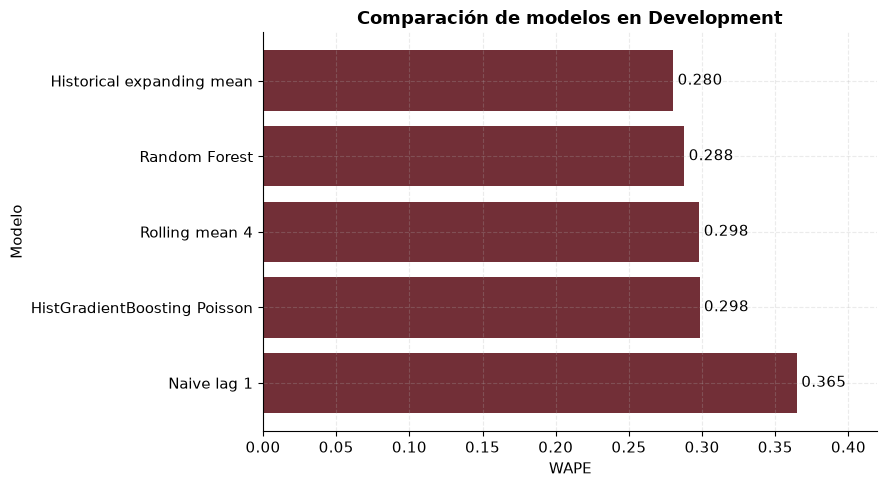

In [24]:
# Figura 1 — WAPE de los modelos en Development

plot_leaderboard = (
    development_leaderboard
    .sort_values(
        'WAPE',
        ascending=True,
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    plot_leaderboard['model'],
    plot_leaderboard['WAPE'],
)

ax.invert_yaxis()

ax.set_title(
    'Comparación de modelos en Development'
)
ax.set_xlabel('WAPE')
ax.set_ylabel('Modelo')

for bar, value in zip(
    bars,
    plot_leaderboard['WAPE'],
):
    ax.text(
        value + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
    )

ax.set_xlim(
    0,
    plot_leaderboard['WAPE'].max() * 1.15,
)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / 'development_model_wape.png'
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
plt.close()


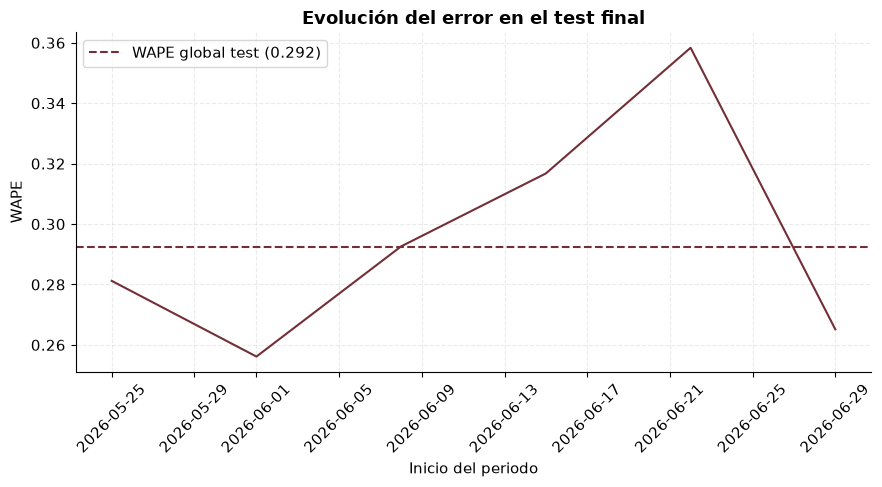

In [25]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    period_test_metrics['report_start'],
    period_test_metrics['WAPE'],
)

ax.axhline(
    y=float(
        selected_final_metrics['WAPE']
    ),
    linestyle='--',
    label=(
        'WAPE global test '
        f'({selected_final_metrics["WAPE"]:.3f})'
    ),
)

ax.set_title(
    'Evolución del error en el test final'
)
ax.set_xlabel('Inicio del periodo')
ax.set_ylabel('WAPE')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / 'final_test_wape_by_period.png'
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
plt.close()


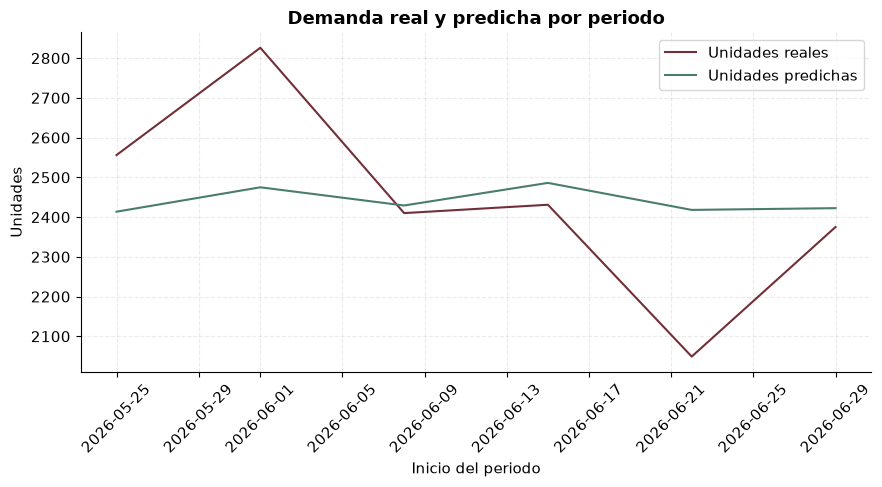

In [26]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    period_test_metrics['report_start'],
    period_test_metrics['actual_units'],
    label='Unidades reales',
)

ax.plot(
    period_test_metrics['report_start'],
    period_test_metrics['predicted_units'],
    label='Unidades predichas',
)

ax.set_title(
    'Demanda real y predicha por periodo'
)
ax.set_xlabel('Inicio del periodo')
ax.set_ylabel('Unidades')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / 'final_test_actual_vs_predicted_units.png'
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
plt.close()


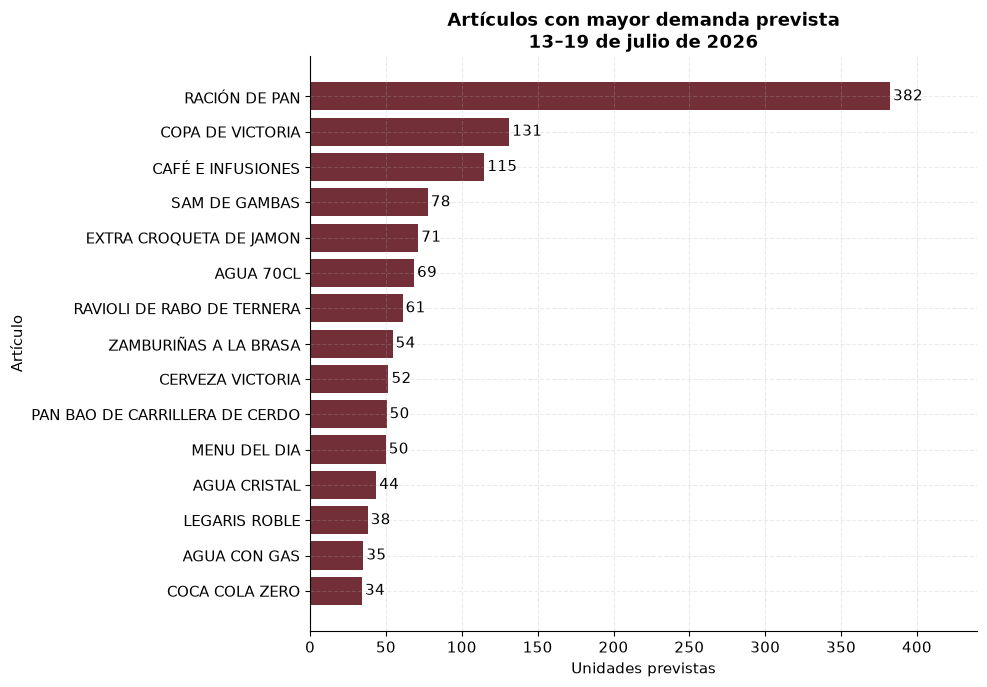

In [27]:


top_forecast = (
    operational_forecast
    .head(15)
    .sort_values(
        'predicted_units',
        ascending=True,
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

bars = ax.barh(
    top_forecast['article_name'],
    top_forecast['predicted_units'],
)

ax.set_title(
    'Artículos con mayor demanda prevista\n'
    '13–19 de julio de 2026'
)
ax.set_xlabel('Unidades previstas')
ax.set_ylabel('Artículo')

for bar, value in zip(
    bars,
    top_forecast['predicted_units'],
):
    ax.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.0f}',
        va='center',
    )

ax.set_xlim(
    0,
    top_forecast['predicted_units'].max() * 1.15,
)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / 'next_period_top15_forecast.png'
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
plt.close()


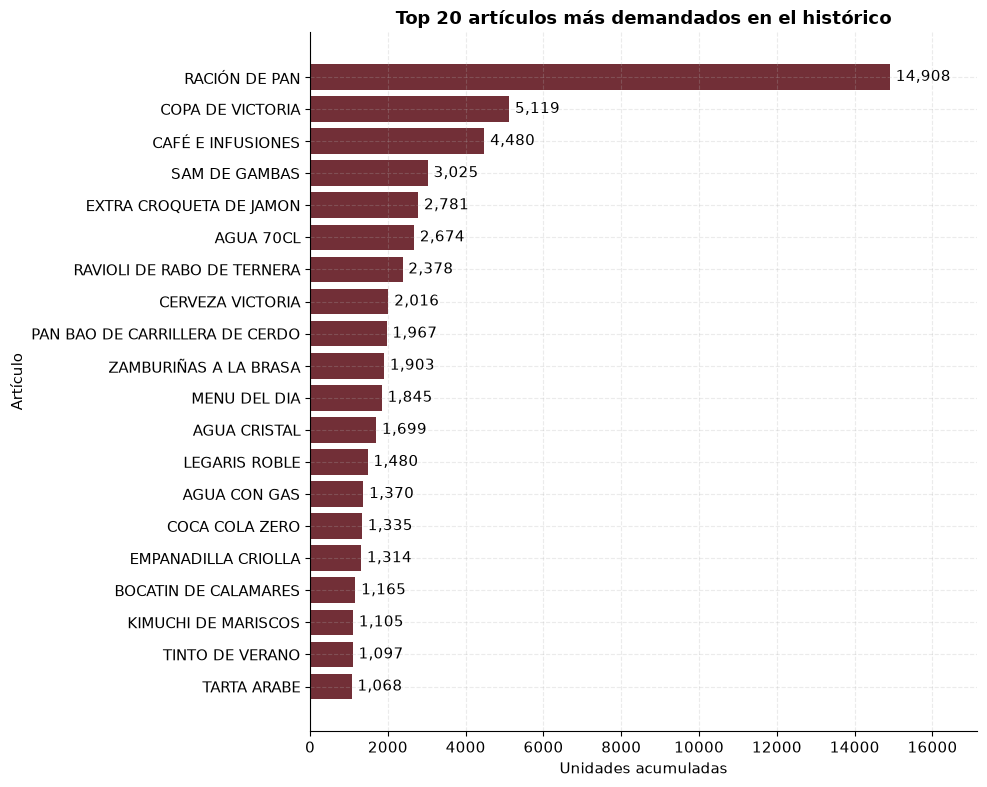

,article_code,article_name,total_units,units_share
19,96,RACIÓN DE PAN,14908.0,0.272397
31,1637,COPA DE VICTORIA,5119.0,0.093534
34,1690,CAFÉ E INFUSIONES,4480.0,0.081858
113,2138,SAM DE GAMBAS,3025.0,0.055272
75,1945,EXTRA CROQUETA DE JAMON,2781.0,0.050814
180,2309,AGUA 70CL,2674.0,0.048859
1,2,RAVIOLI DE RABO DE TERNERA,2378.0,0.043450
35,1691,CERVEZA VICTORIA,2016.0,0.036836
225,2381,PAN BAO DE CARRILLERA DE CERDO,1967.0,0.035941
80,1974,ZAMBURIÑAS A LA BRASA,1903.0,0.034771


In [28]:

top20_historico = (
    model_data
    .groupby(
        [
            'article_code',
            'article_name',
        ],
        as_index=False,
    )['units']
    .sum()
    .rename(
        columns={
            'units': 'total_units',
        }
    )
    .sort_values(
        'total_units',
        ascending=False,
    )
    .head(20)
    .copy()
)

top20_historico['units_share'] = (
    top20_historico['total_units']
    / top20_historico['total_units'].sum()
)

top20_plot = top20_historico.sort_values(
    'total_units',
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

bars = ax.barh(
    top20_plot['article_name'],
    top20_plot['total_units'],
)

ax.set_title(
    'Top 20 artículos más demandados en el histórico'
)
ax.set_xlabel('Unidades acumuladas')
ax.set_ylabel('Artículo')

for bar, value in zip(
    bars,
    top20_plot['total_units'],
):
    ax.text(
        value + top20_plot['total_units'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
    )

ax.set_xlim(
    0,
    top20_plot['total_units'].max() * 1.15,
)

plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / 'top20_articulos_historico.png'
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight',
)

plt.show()
plt.close()


display(
    top20_historico[
        [
            'article_code',
            'article_name',
            'total_units',
            'units_share',
        ]
    ]
)

## 19. Conclusiones

Este notebook ha desarrollado un sistema de predicción de comandas orientado a
estimar la demanda semanal de artículos de La Roca.

El histórico disponible contiene 41 periodos de ventas, de los cuales 39 son
periodos completos de siete días. Tras excluir los dos periodos incompletos, el
dataset de modelado contiene **5.314 observaciones correspondientes a 251
artículos**.

La estructura del histórico presenta una elevada dispersión: únicamente el
54,3 % de las combinaciones posibles artículo x periodo están observadas.
Estas ausencias no se han interpretado automáticamente como demanda cero, ya
que la información disponible no permite distinguir entre ausencia de demanda,
indisponibilidad del producto o retirada temporal de carta.

### Validación temporal

Los últimos seis periodos completos se reservaron como test final, manteniéndolos
completamente fuera del proceso de selección. Los 33 periodos anteriores se
utilizaron como Development y se evaluaron mediante cuatro folds temporales de
ventana expansiva.

La métrica principal de selección fue WAPE. Los resultados obtenidos sobre
Development fueron:

| Modelo | WAPE |
|---|---:|
| Historical expanding mean | **0,2803** |
| Random Forest | 0,2878 |
| Rolling mean 4 | 0,2982 |
| HistGradientBoosting Poisson | 0,2983 |
| Naive lag 1 | 0,3648 |

La estrategia con menor error fue, por tanto, **Historical expanding mean**,
que predice la demanda de cada artículo utilizando la media de todas sus
observaciones históricas anteriores.

Este resultado muestra que, con la cantidad y estructura de datos disponibles,
los modelos de Machine Learning evaluados no proporcionan una mejora robusta
frente a una referencia estadística sencilla. En consecuencia, se seleccionó
la alternativa de menor complejidad y mejor rendimiento fuera de muestra en
Development.

### Evaluación final

Una vez congelada la decisión, el modelo seleccionado se evaluó sobre los seis
periodos reservados como test final, obteniendo:

- **WAPE:** 0,2923;
- **MAE:** 5,40 unidades;
- **RMSE:** 9,42 unidades;
- **Bias:** -0,0002;
- **Top-20 overlap:** 0,7833.

El Bias prácticamente nulo indica que, en términos agregados, no existe una
tendencia sistemática a sobrepredecir o infrapredecir la demanda. Sin embargo,
el análisis por artículo muestra desviaciones relevantes en determinados
productos.

Los 20 artículos con mayor error concentran aproximadamente el **49 % del error
absoluto total**, lo que muestra cierta concentración del error, aunque no
permite atribuir el rendimiento global a un número muy reducido de productos.

El ranking de modelos obtenido sobre test es diferente al observado en
Development. Este resultado no se utilizó para modificar la selección, ya que
el test se mantiene exclusivamente como medida final de generalización.

### Forecast operacional

Finalmente, se generó una previsión para el periodo comprendido entre el
**13 y el 19 de julio de 2026**.

Al no existir una señal autoritativa sobre la vigencia de los artículos en
carta, el forecast operativo se restringió de forma conservadora a los
productos observados al menos una vez durante los cuatro últimos periodos
completos. Bajo este criterio se identificaron **170 artículos con actividad
reciente**.

Entre los artículos con mayor demanda prevista se encuentran:

- **RACIÓN DE PAN:** aproximadamente 382 unidades;
- **COPA DE VICTORIA:** aproximadamente 131 unidades;
- **CAFÉ E INFUSIONES:** aproximadamente 115 unidades.

El listado completo se exporta automáticamente a
`results/predictions/next_period_article_forecast.csv`.

### Limitaciones

La principal limitación del análisis es la ausencia de información histórica
explícita sobre disponibilidad de cada producto. Por este motivo, una ausencia
`artículo x periodo` no puede interpretarse con certeza como demanda nula.

Asimismo, no se incorpora meteorología observada al modelo, ya que para una
utilización operacional sería necesario disponer de previsiones meteorológicas
equivalentes a las que estarían disponibles en el momento de realizar cada
predicción histórica.

Las reservas tampoco se incorporan como predictor de comandas en esta versión,
ya que sería necesario reconstruir para cada periodo el conjunto de reservas
que era conocido exactamente en el instante de realizar la predicción.

Como líneas futuras, la disponibilidad histórica de artículos, la incorporación
de snapshots de reservas, forecasts meteorológicos históricos y una tabla de
recetas que transforme artículos previstos en necesidades de ingredientes
permitirían ampliar considerablemente la utilidad operacional del sistema.

En conjunto, los resultados muestran que una metodología de validación temporal
rigurosa y la comparación explícita frente a baselines sencillos son esenciales
antes de justificar el uso de modelos más complejos. En este caso, una estrategia
estadística simple ofrece la solución más robusta con la información disponible.